In [104]:

import numpy as np 
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model 
plt.style.use('ggplot')


# sns.set(style="ticks", context="talk")
sns.set_theme(palette="viridis", style="ticks")
plt.style.use("dark_background")



# Sensitivity analysis of the model

### Introduction:

Model parameters are often chosen while building based on what feels right at the moment. As the number of parameters grow, it becomes really hard to disceratain which parameters actually affect model scores significantly. 
Our sensitivity analysis is mainly to understand which parameters play a role in echolocation in groups, especially when it comes to utilizing our consistency based approach to do so.

### Methods:



## 0. Setting up the model null
### Entropy stats
The description of the entropy of the system are described below. Among all our model parameters only speed affects the entropy.


In [2]:
null_model_data = "../../Data/AnalysisData/null_model_scores.csv"
df_null_model = pd.read_csv(null_model_data)
df_null_model["identifier"] = "null"

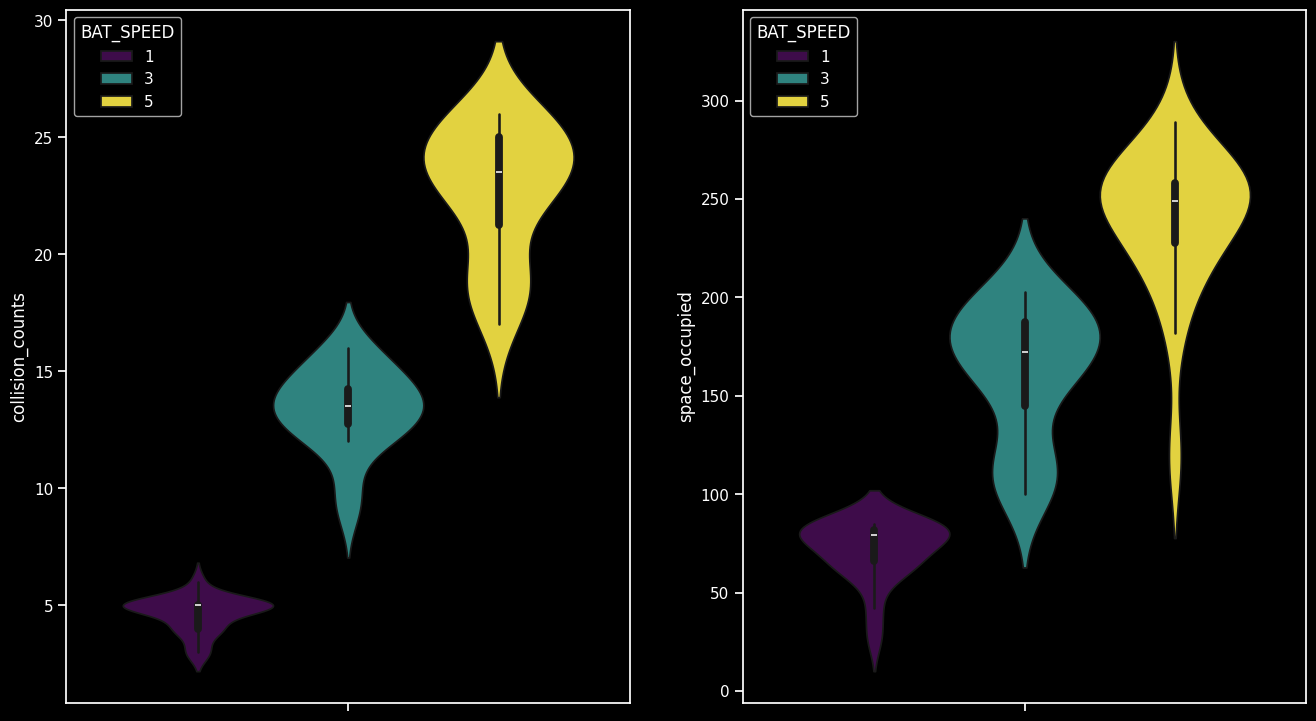

In [3]:
%matplotlib inline
plt.figure(figsize=(16,9))
plt.subplot(1,2,1)
sns.violinplot(df_null_model, hue="BAT_SPEED", y="collision_counts", palette="viridis")
plt.subplot(1,2,2)
sns.violinplot(df_null_model, hue="BAT_SPEED", y="space_occupied", palette="viridis")
plt.show()

In [4]:
mean_null_collisions = df_null_model.groupby("BAT_SPEED")["collision_counts"].mean()
mean_null_collisions

BAT_SPEED
1     4.65
3    13.35
5    22.70
Name: collision_counts, dtype: float64

Our model output has to be significantly different than the null in order for it to be good enough. 

This only applies to collision counts. Model has to collide significantly less often than the null model. For space occupied it doesn't matter.

# 1. Analyzing data
### 1.0 Understanding parameters
Let's first look at overall variation of scores over all our parameters. 


In [3]:

analysis_data_dir = r"../../Data/AnalysisData/sensitivity_analysis_data.csv"
df_overall_model = pd.read_csv(analysis_data_dir)
df_overall_model["TEMPORAL_MASKING_FN_TYPE_ONE_HOT"] = [1 if i=="full" else 0 for i in df_overall_model["TEMPORAL_MASKING_FN_TYPE"]]
df_overall_model.to_csv("sensitivity_analysis_data_for_R.csv")
df_overall_model["identifier"] = "treatment"

<Axes: ylabel='space_occupied'>

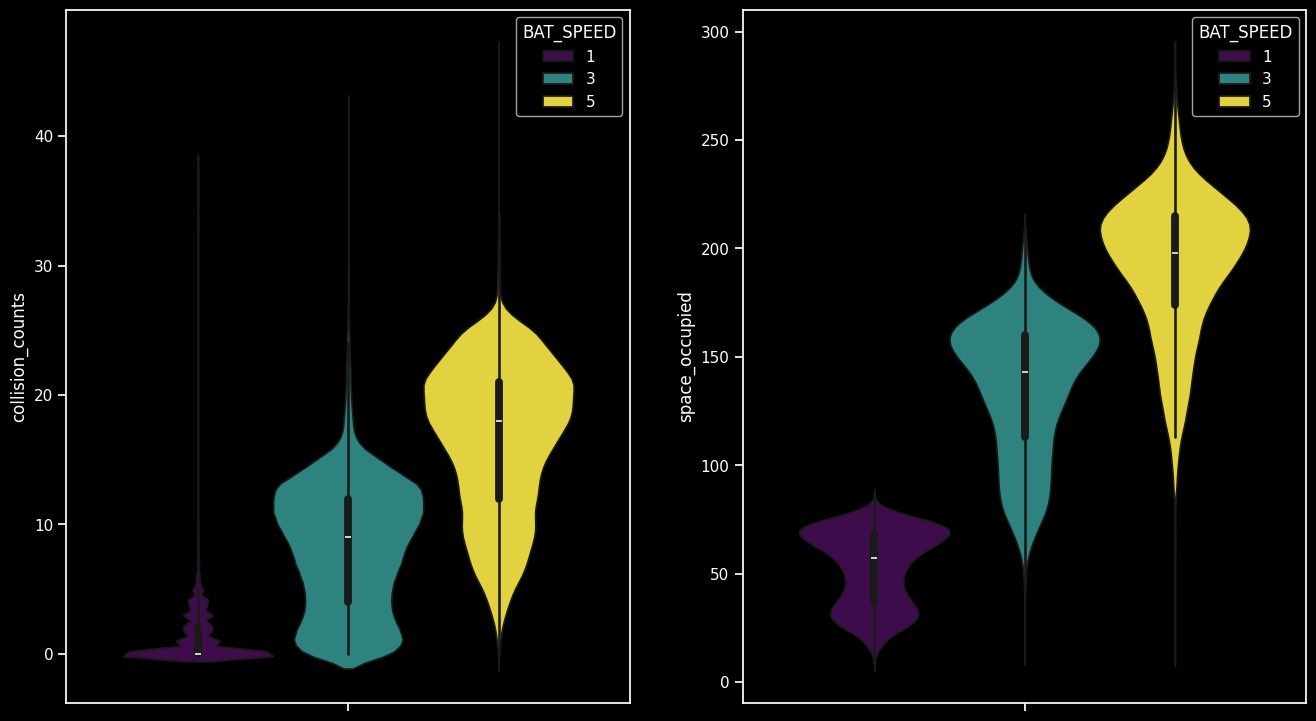

In [6]:
%matplotlib inline
plt.figure(figsize=(16,9))
plt.subplot(1,2,1)
sns.violinplot(df_overall_model, hue="BAT_SPEED", y="collision_counts", palette="viridis")
plt.subplot(1,2,2)
sns.violinplot(df_overall_model, hue="BAT_SPEED", y="space_occupied", palette="viridis")

<Axes: xlabel='collision_counts', ylabel='space_occupied'>

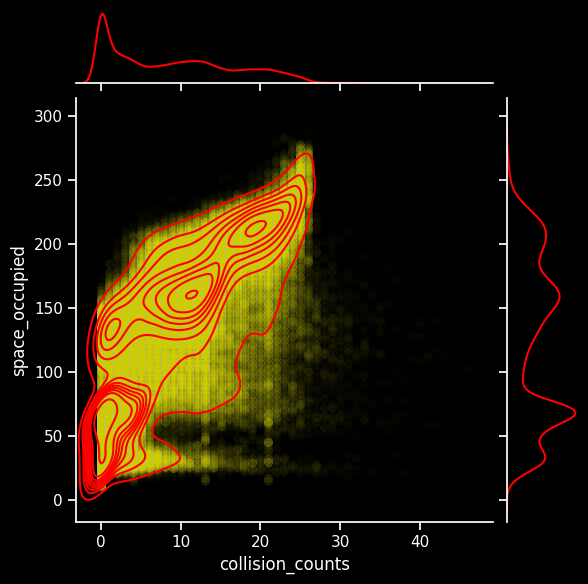

In [7]:
sns.jointplot(df_overall_model, x="collision_counts", y="space_occupied", kind="kde", color="red")
sns.scatterplot(df_overall_model, x="collision_counts", y="space_occupied", alpha =0.02, color="yellow")


<Axes: xlabel='BAT_SPEED', ylabel='space_occupied'>

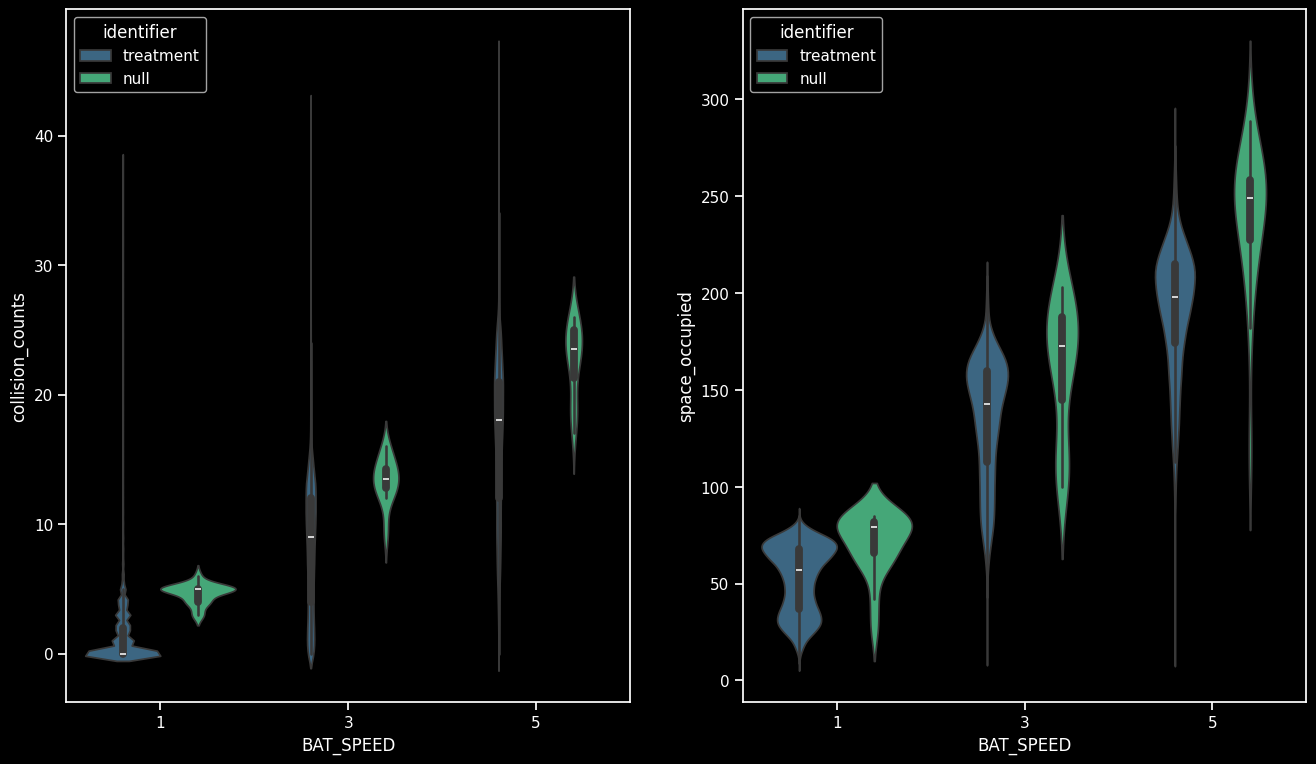

In [8]:
# lets merge to see them next to each other
df_merged = pd.concat((df_overall_model,df_null_model))
%matplotlib inline
plt.figure(figsize=(16,9))
plt.subplot(1,2,1)
sns.violinplot(df_merged, x="BAT_SPEED", y="collision_counts", hue="identifier", palette="viridis")
plt.subplot(1,2,2)
sns.violinplot(df_merged, x="BAT_SPEED", y="space_occupied", hue="identifier", palette="viridis")

In [9]:
# resample up the null
df_merged_resampled = df_merged
for i in range(1400):
    df_merged_resampled = pd.concat((df_merged_resampled, df_null_model))

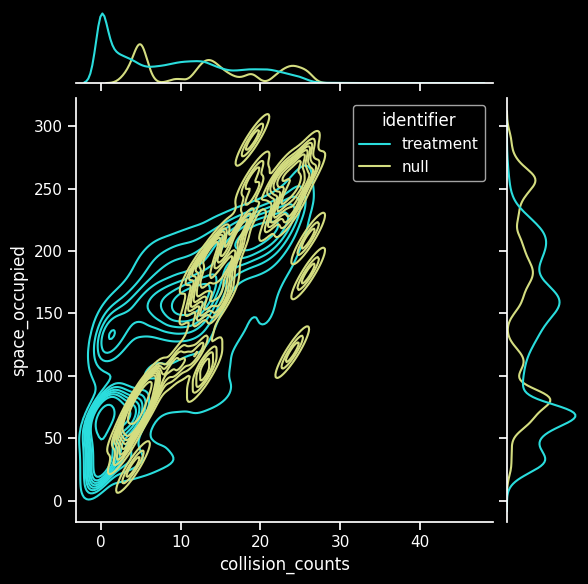

In [10]:
sns.jointplot(df_merged_resampled, x="collision_counts", y="space_occupied",hue="identifier", kind="kde", palette="rainbow")

Overall seems like a lot of points are below the null, positive results! Model works for a lot of parameter combinations. Also, note however a lot of points are well over null. Its important to acknowledge that. 

Space occupied will ofc be less than the null because a model that avoids walls is by default going to explore lesser space. 

## 1.1 What does the best case look like?
Best case is ofcourse 0 collisions here. Let's see what the variance of the parameters is like when collision rate is 0.

Text(0.5, 0, 'bat speed')

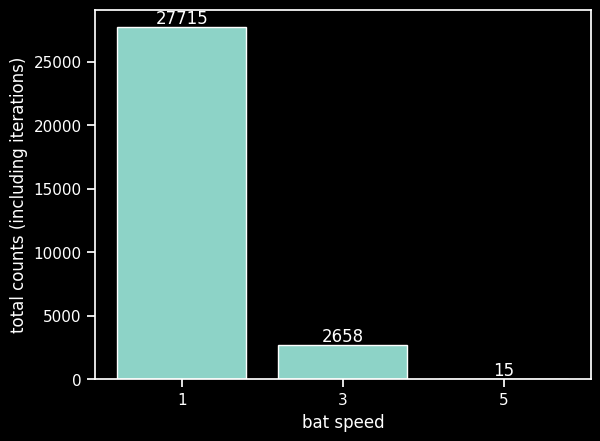

In [11]:
df_zero_collisions = df_overall_model[(df_overall_model["collision_counts"]==0)]
bat_speeds = [1,3,5]
counts_zero_collision = [len(df_zero_collisions[df_zero_collisions["BAT_SPEED"]==i]) for i in bat_speeds]
fig, ax = plt.subplots()
bat_speeds = ["1", "3", "5"]
ax = ax.bar(bat_speeds, counts_zero_collision)
plt.bar_label(ax)
plt.ylabel("total counts (including iterations)")
plt.xlabel("bat speed")

<Axes: xlabel='BAT_SPEED', ylabel='space_occupied'>

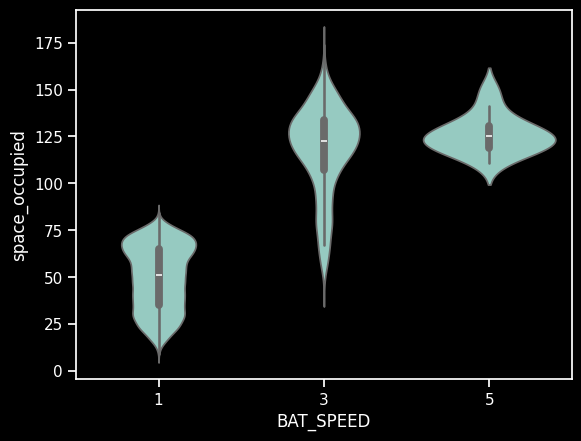

In [12]:
sns.violinplot(df_zero_collisions, x="BAT_SPEED", y="space_occupied")

In [13]:
# these are the parameters that were varied during the simulations
varying_params = np.array([
    "CALL_DURATION",
    "CALL_RATE_FAST",
    "HEARING_THRESHOLD",
    "CALL_DIRECTIONALITY",
    "TEMPORAL_MASKING_FN_TYPE",
    "TIME_DELAY_FOR_DIRECTION_CHANGE",
    "BAT_RADIAL_RESOLUTION",
    "MEMORY_WINDOW_FOR_CONSISTENCY",
    "BAT_FRONTAL_RANGE",
])
number_of_params = len(varying_params)

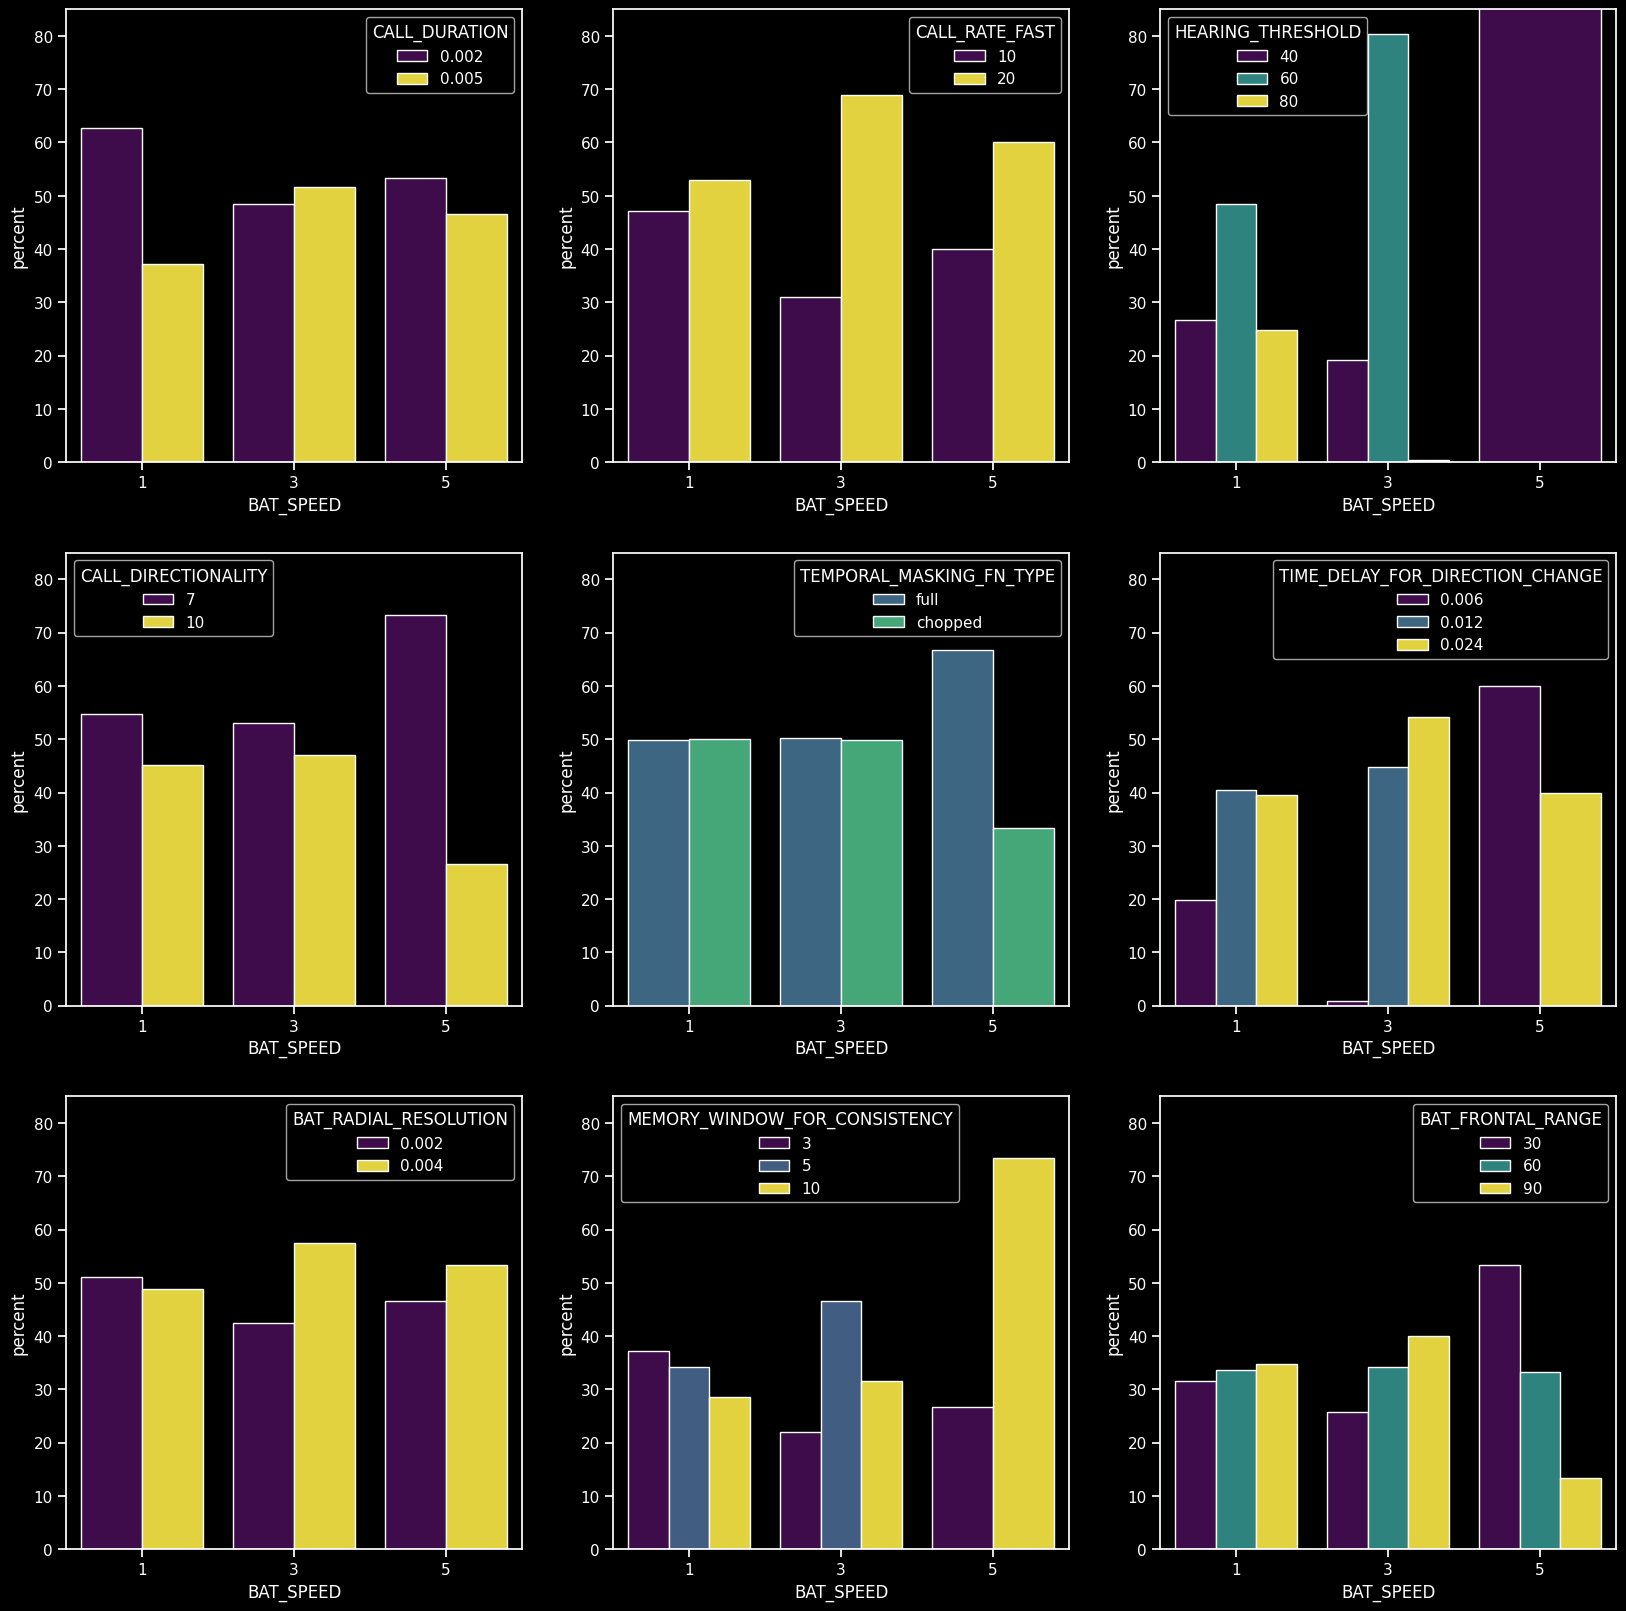

In [14]:

%matplotlib inline
plt.figure(figsize=(20,20))
number_of_subfigs = int(np.ceil(number_of_params/3))
bat_speeds = [1,3,5]
for bat_speed in bat_speeds:
    legend = True if bat_speed == 1 else False
    for i, param in enumerate(varying_params):
        df_zero_collisions = df_overall_model[(df_overall_model["collision_counts"]==0) & (df_overall_model["BAT_SPEED"]==bat_speed)]
        plt.subplot(3,number_of_subfigs,i+1)
        sns.countplot(df_zero_collisions, x="BAT_SPEED", hue=param, stat="percent", legend=legend, palette= "viridis")
        plt.ylim(0,85)



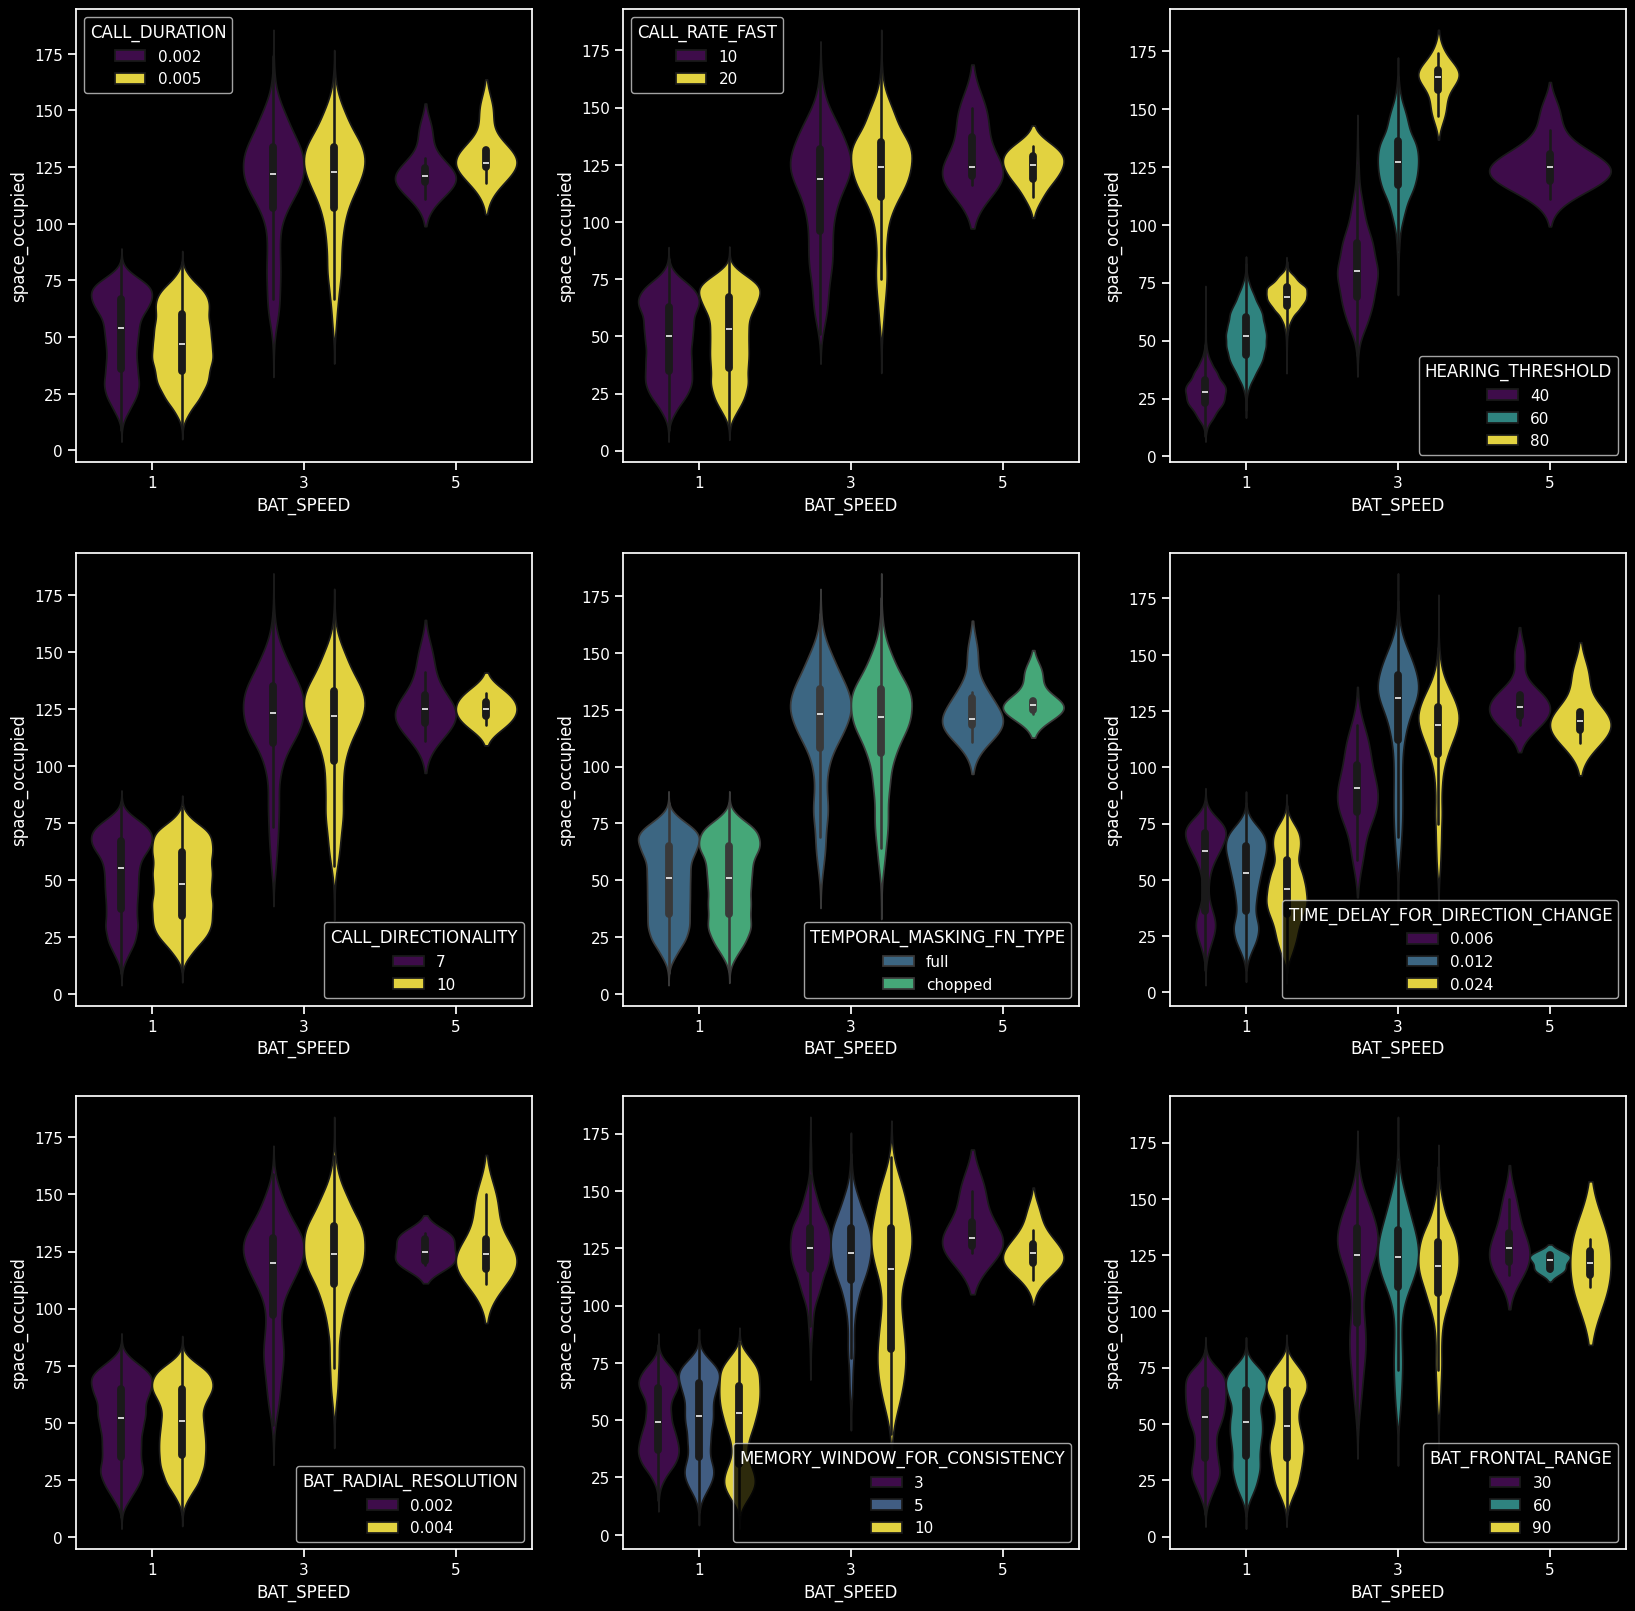

In [15]:
%matplotlib inline
plt.figure(figsize=(20,20))
number_of_subfigs = int(np.ceil(number_of_params/3))
bat_speeds = [1,3,5]
for bat_speed in bat_speeds:
    legend = True if bat_speed == 1 else False
    for i, param in enumerate(varying_params):
        df_zero_collisions = df_overall_model[(df_overall_model["collision_counts"]==0) & (df_overall_model["BAT_SPEED"]==bat_speed)]
        plt.subplot(3,number_of_subfigs,i+1)
        sns.violinplot(df_zero_collisions, x="BAT_SPEED", y="space_occupied", hue=param, legend=legend, palette= "viridis")
        # plt.ylim(0,85)

** EXPLAIN RESULTS HERE **

That wasnt very fair for bat speed of 5 cause base collision rate is ofc high when speed is high!

Let's fix how we think of low collisions. Now low collisions would mean less than quater of the mean collision count of the null model.

In [16]:
df_low_collisions = df_overall_model
mean_null_collisions = {1:1, 3:4, 5:10}
df_low_collisions["mean_null_collision_counts"] = [mean_null_collisions[i] for i in df_low_collisions["BAT_SPEED"]]
# df_zero_collisions = df_overall_model[(df_overall_model["collision_counts"]<) & (df_overall_model["BAT_SPEED"]==bat_speed)]
df_low_collisions = df_low_collisions[df_low_collisions["collision_counts"]<df_low_collisions["mean_null_collision_counts"]]
df_low_collisions

,Unnamed: 0.1,Unnamed: 0,space_occupied,collision_counts,collision_rate,calling_effort,iteration_label,SOUND_SPEED,SIM_DURATION,TIME_STEP,...,BEHAVIOUR_RULE,CONTROLLER_TYPE,STORE_HEARING,JAMMER_RESOLUTION,TEMPORAL_MASKING_FN_TYPE,OUTPUT_DIR_FOR_SIMULATION,PARAM_LABEL,TEMPORAL_MASKING_FN_TYPE_ONE_HOT,identifier,mean_null_collision_counts
1,1,1,67,0,0.000000,300,iteration_number_1,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment,1
3,3,3,69,0,0.000000,301,iteration_number_3,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment,1
4,4,4,67,0,0.000000,299,iteration_number_4,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment,1
5,5,5,67,0,0.000000,298,iteration_number_5,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment,1
8,8,8,69,0,0.000000,301,iteration_number_8,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155495,15,15,139,1,0.003833,389,iteration_number_15,343,30,0.001,...,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_3015/,paramset_3015,0,treatment,4
155496,16,16,128,2,0.009833,362,iteration_number_16,343,30,0.001,...,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_3015/,paramset_3015,0,treatment,4
155497,17,17,127,1,0.005600,358,iteration_number_17,343,30,0.001,...,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_3015/,paramset_3015,0,treatment,4
155498,18,18,124,2,0.009667,357,iteration_number_18,343,30,0.001,...,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_3015/,paramset_3015,0,treatment,4


Text(0.5, 0, 'bat speed')

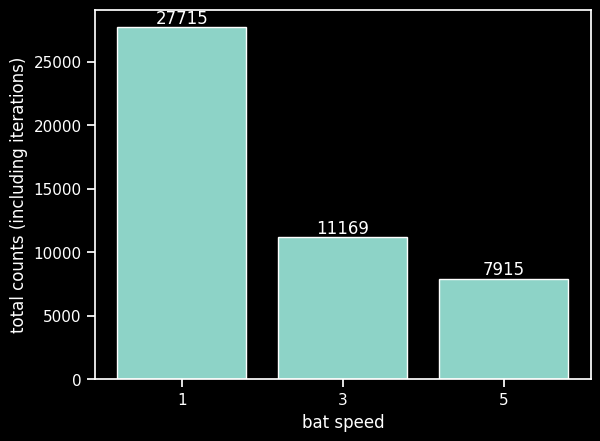

In [17]:
bat_speeds = [1,3,5]
counts_low_collision = [len(df_low_collisions[df_low_collisions["BAT_SPEED"]==i]) for i in bat_speeds]
fig, ax = plt.subplots()
bat_speeds = ["1", "3", "5"]
ax = ax.bar(bat_speeds, counts_low_collision)
plt.bar_label(ax)
plt.ylabel("total counts (including iterations)")
plt.xlabel("bat speed")

<Axes: ylabel='space_occupied'>

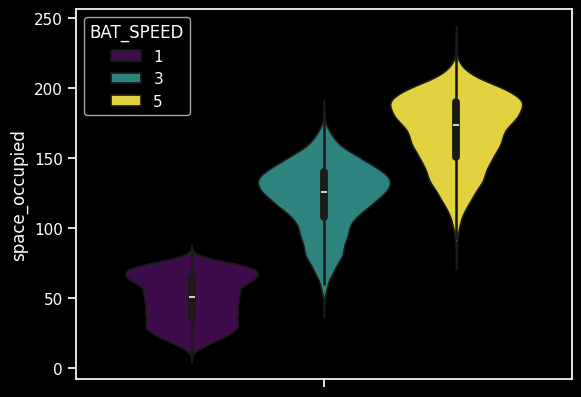

In [18]:
sns.violinplot(df_low_collisions, hue="BAT_SPEED", y="space_occupied", palette="viridis")

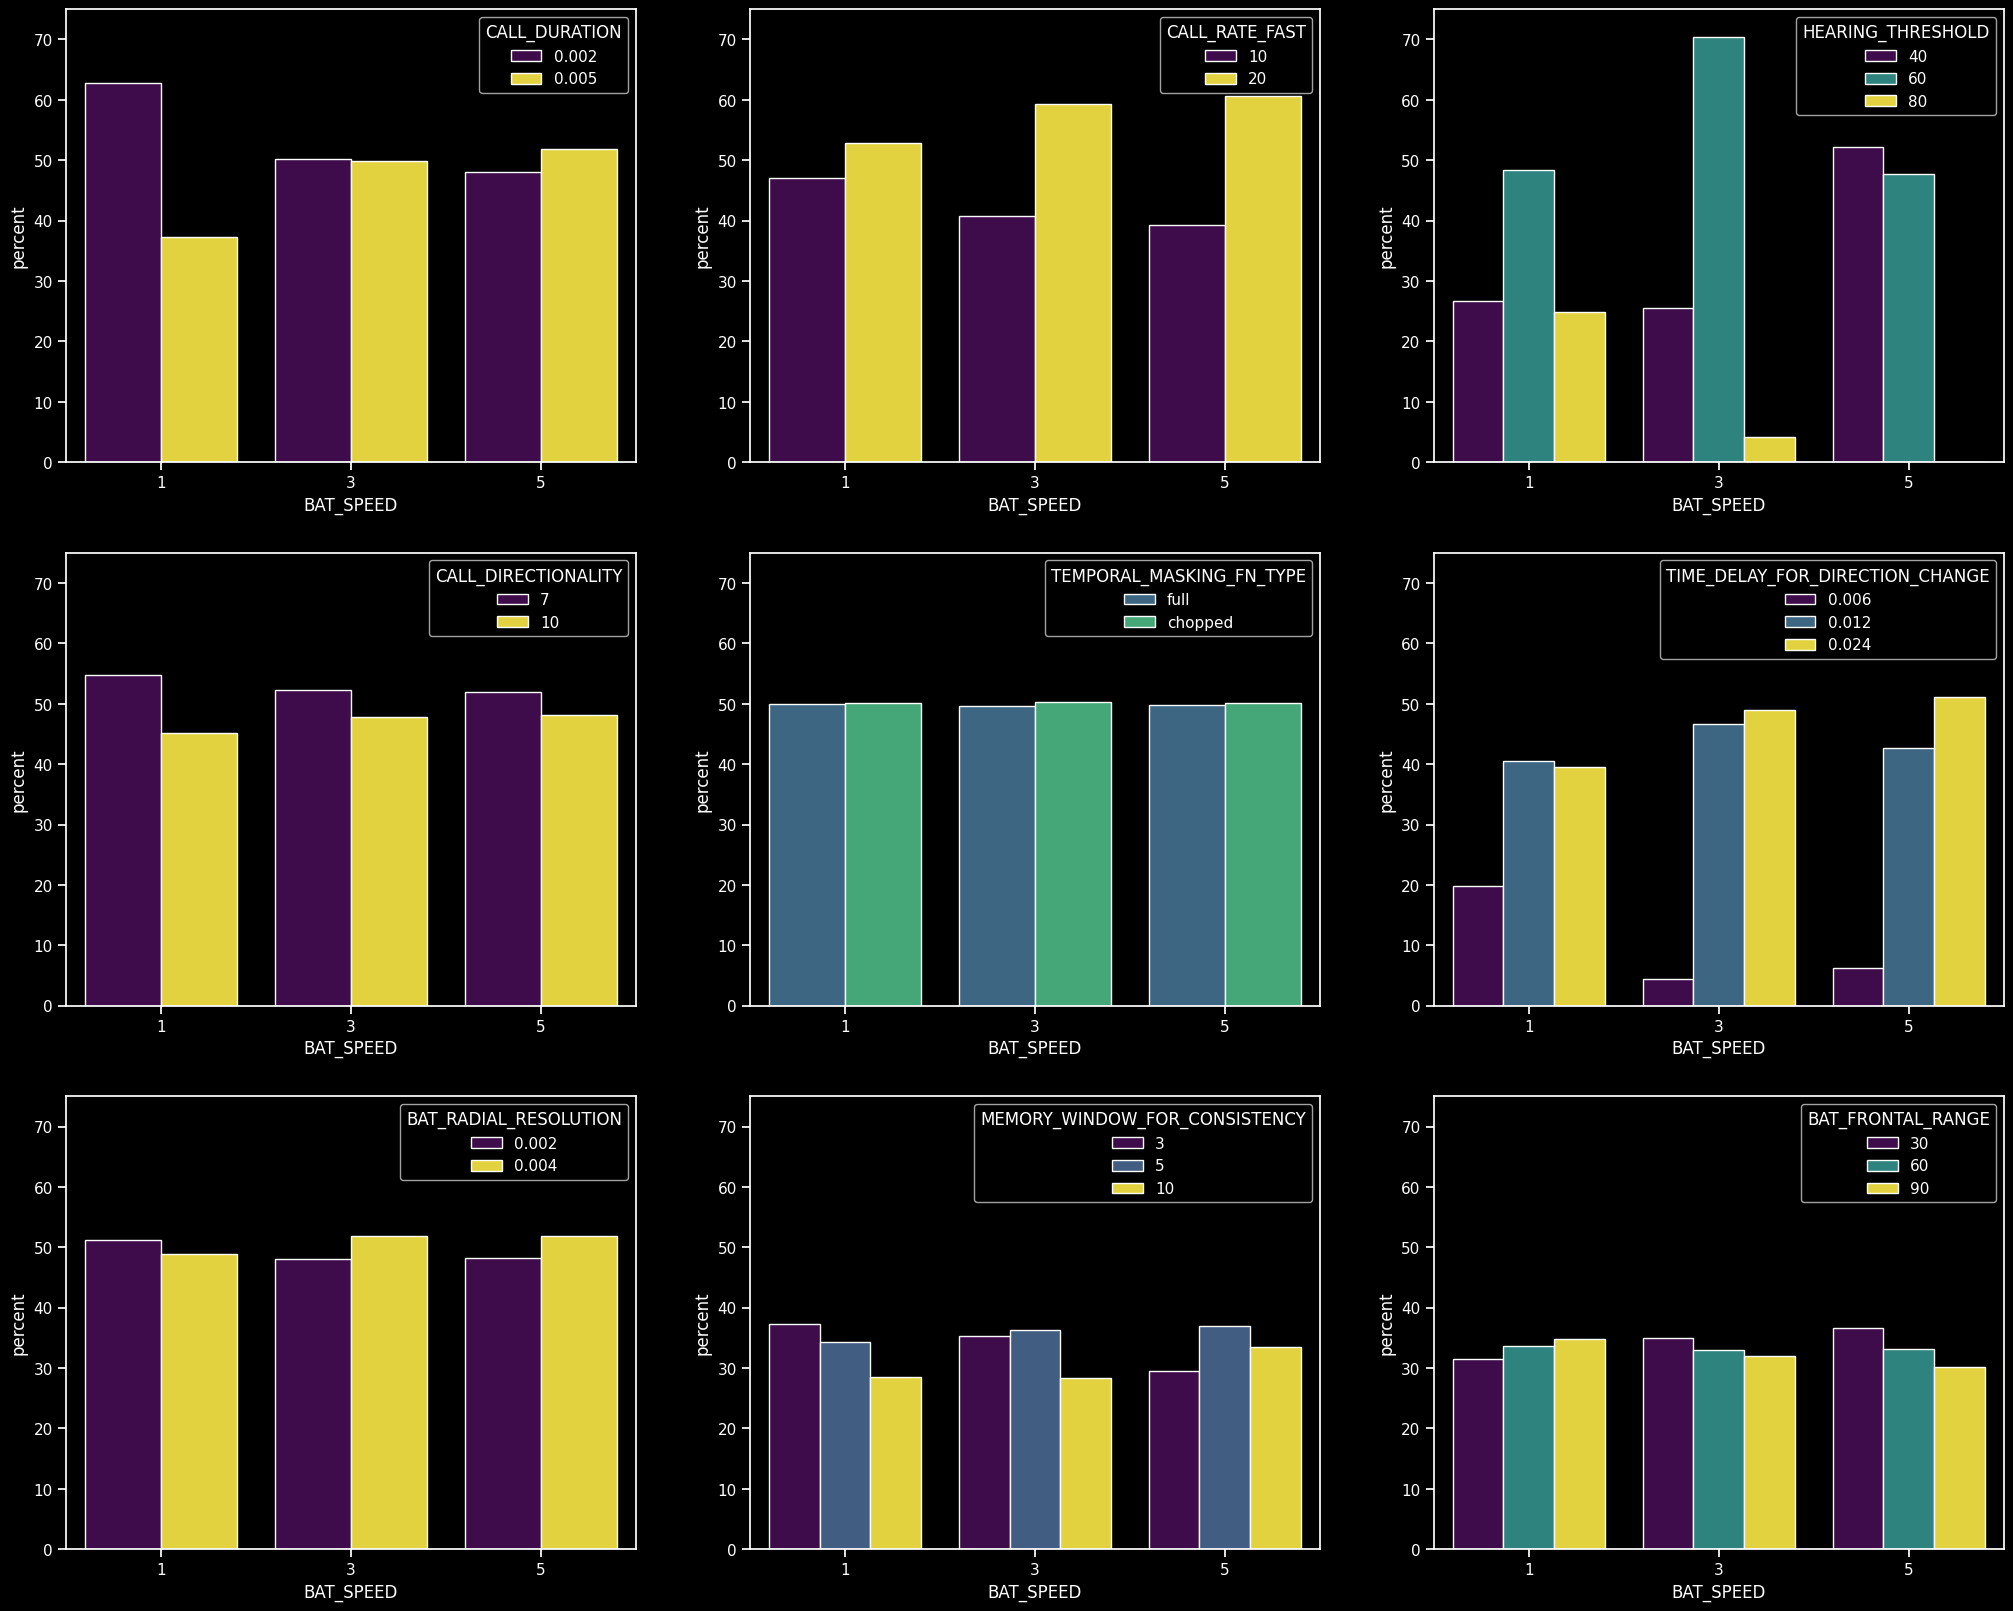

In [19]:

%matplotlib inline
plt.figure(figsize=(25,20))
number_of_subfigs = int(np.ceil(number_of_params/3))
bat_speeds = [1,3,5]
for bat_speed in bat_speeds:
    legend = True if bat_speed == 1 else False
    for i, param in enumerate(varying_params):
        df_low_collisions_given_bat_speed = df_low_collisions[(df_low_collisions["BAT_SPEED"]==bat_speed)]
        plt.subplot(3,number_of_subfigs,i+1)
        sns.countplot(df_low_collisions_given_bat_speed, x="BAT_SPEED", hue=param, stat="percent", legend=legend, palette="viridis")
        plt.ylim(0,75)


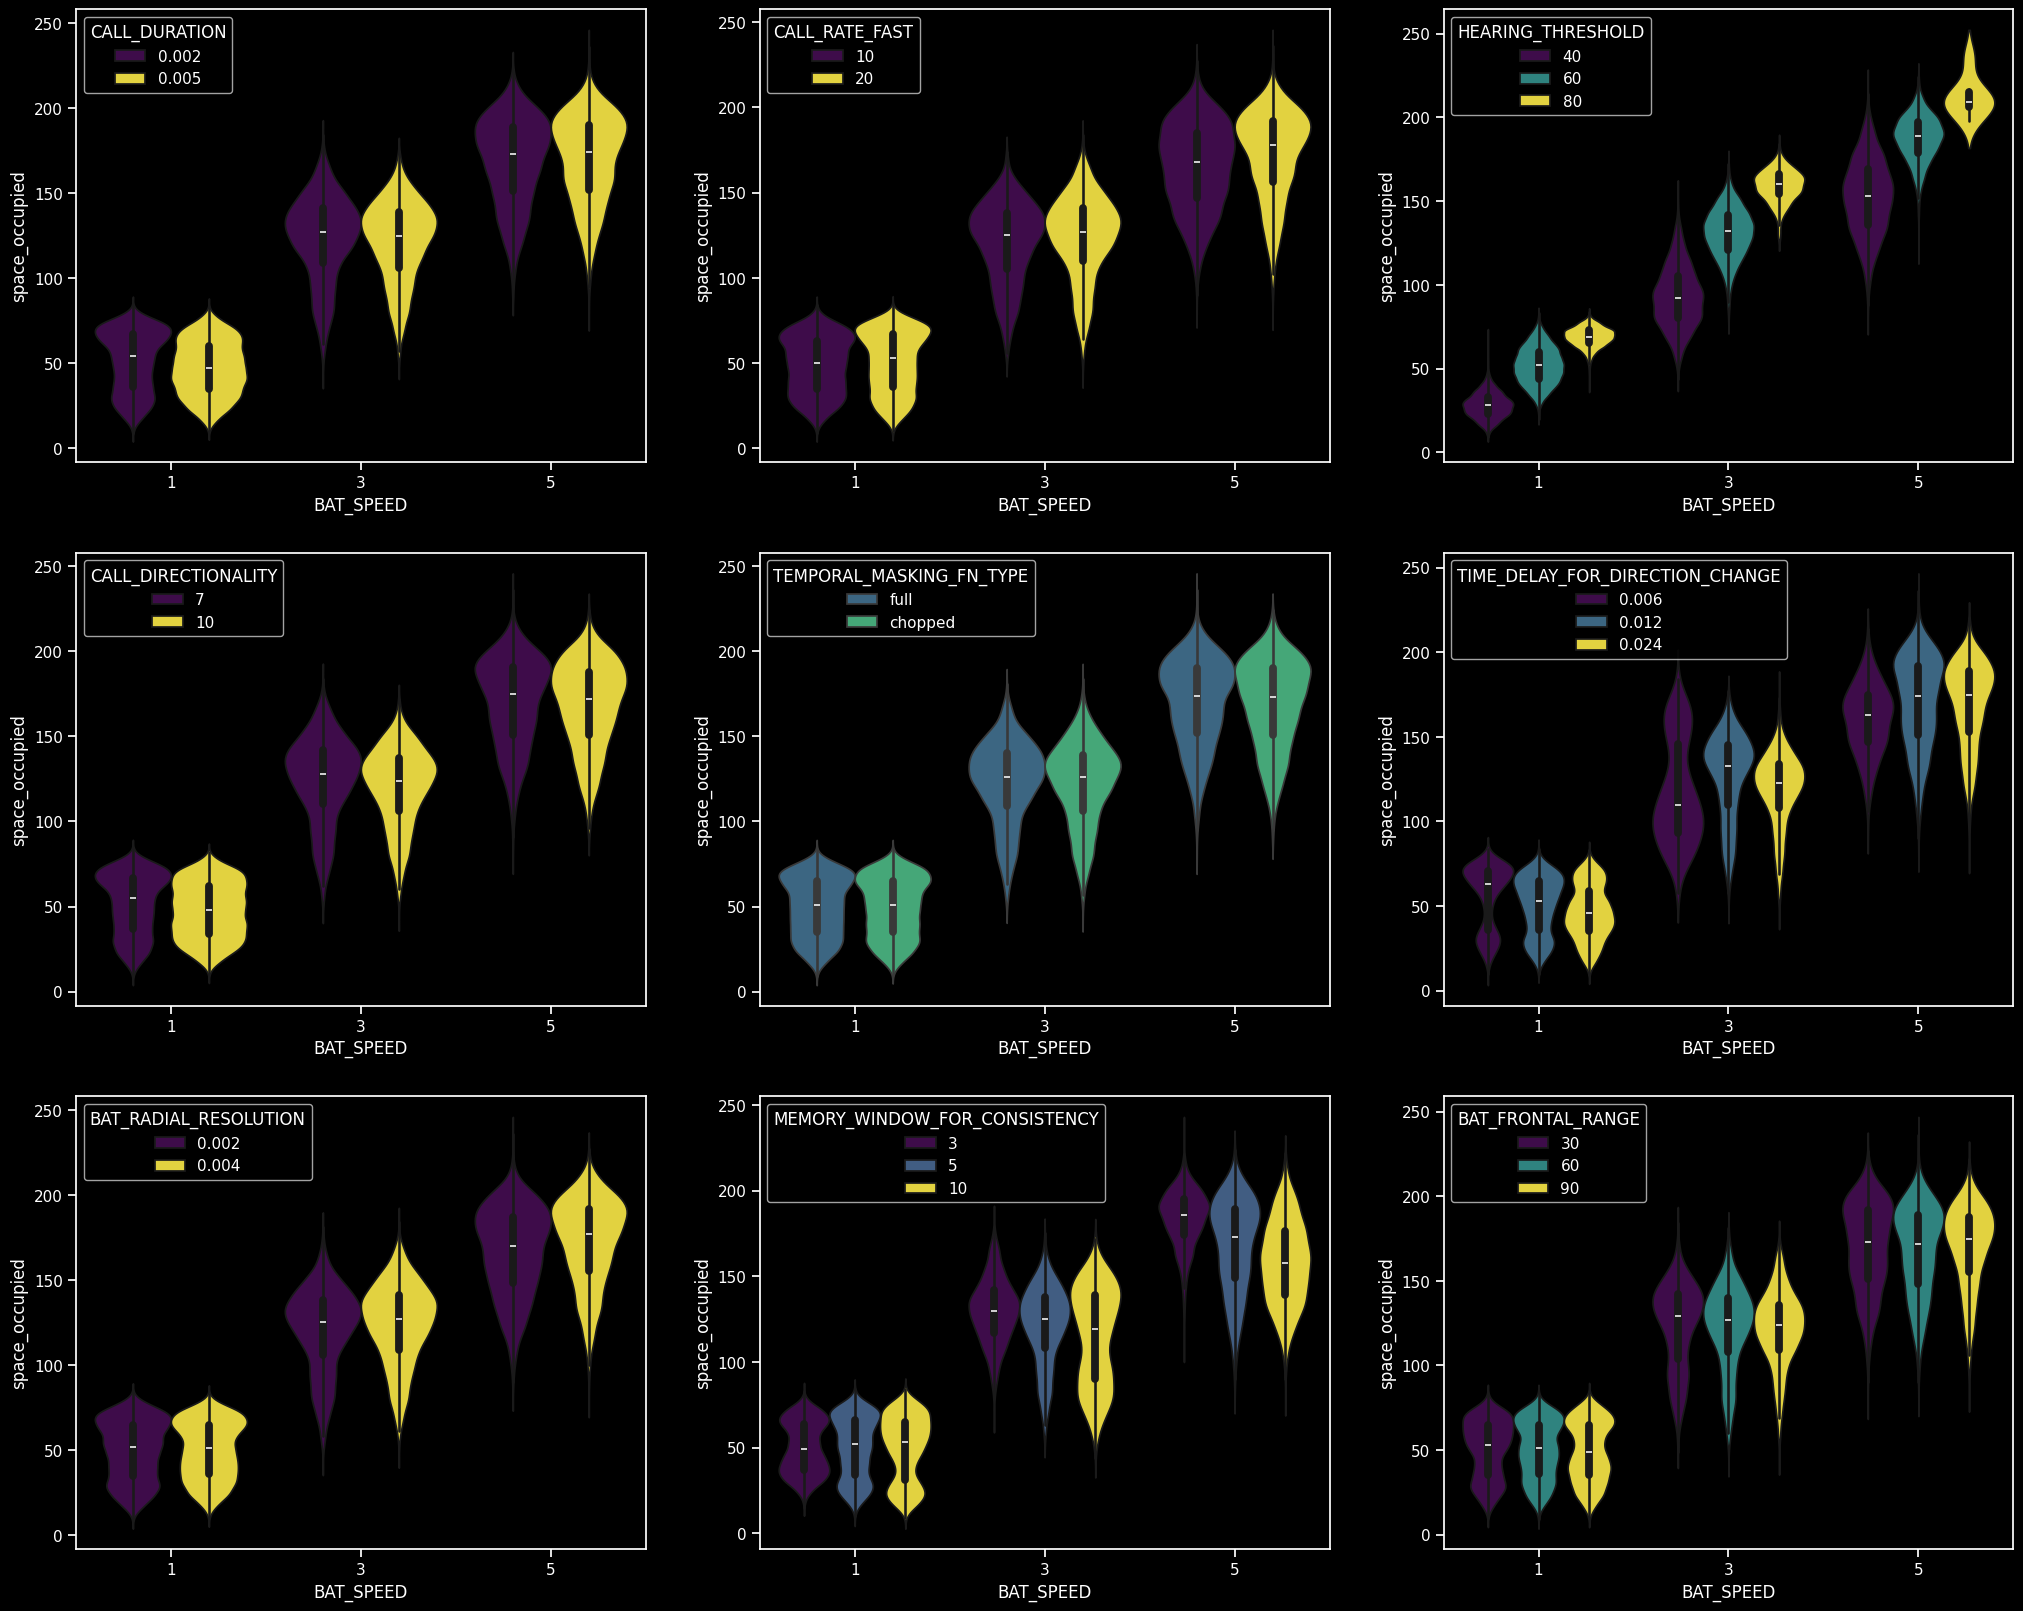

In [20]:
%matplotlib inline
plt.figure(figsize=(25,20))
number_of_subfigs = int(np.ceil(number_of_params/3))
bat_speeds = [1,3,5]
for bat_speed in bat_speeds:
    legend = True if bat_speed == 1 else False
    for i, param in enumerate(varying_params):
        df_low_collisions_given_bat_speed = df_low_collisions[(df_low_collisions["BAT_SPEED"]==bat_speed)]
        plt.subplot(3,number_of_subfigs,i+1)
        sns.violinplot(df_low_collisions_given_bat_speed, x="BAT_SPEED", hue=param, y="space_occupied", legend=legend, palette="viridis")


now that we identified the key variables with respect to collision counts, lets try to look at how the distributions look like for these varibles.

<Figure size 2500x2000 with 0 Axes>

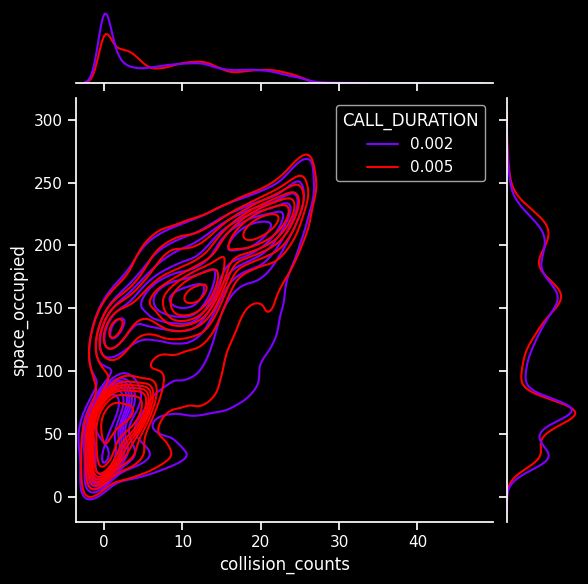

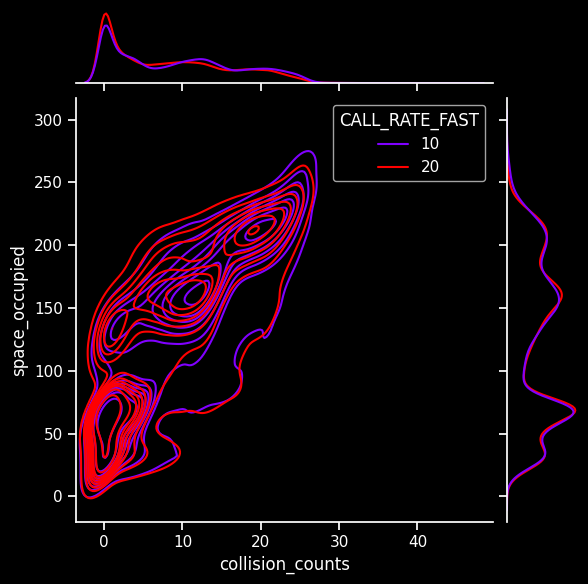

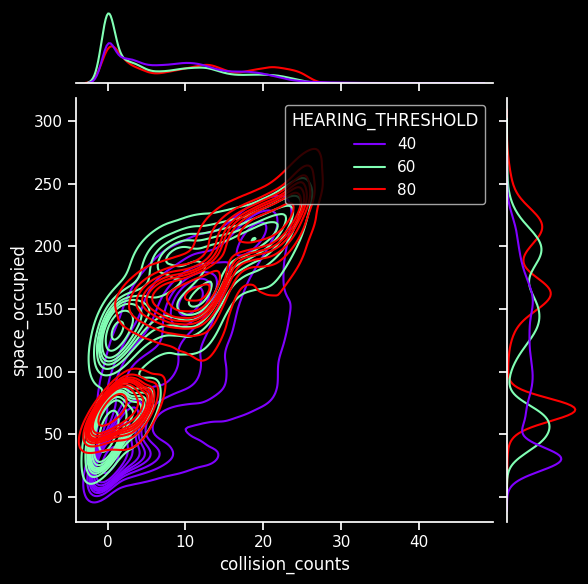

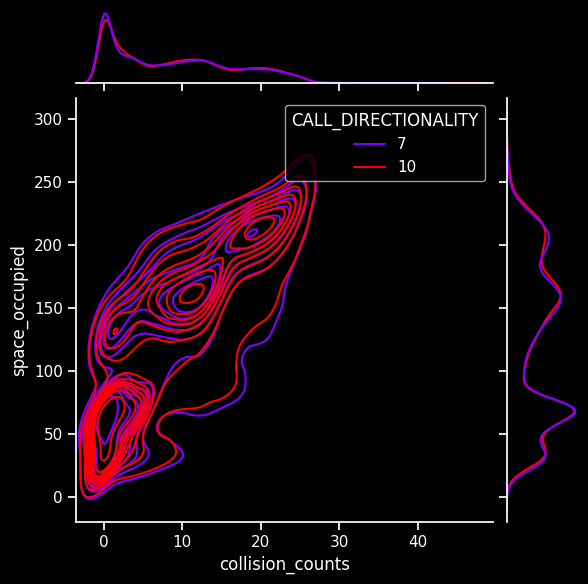

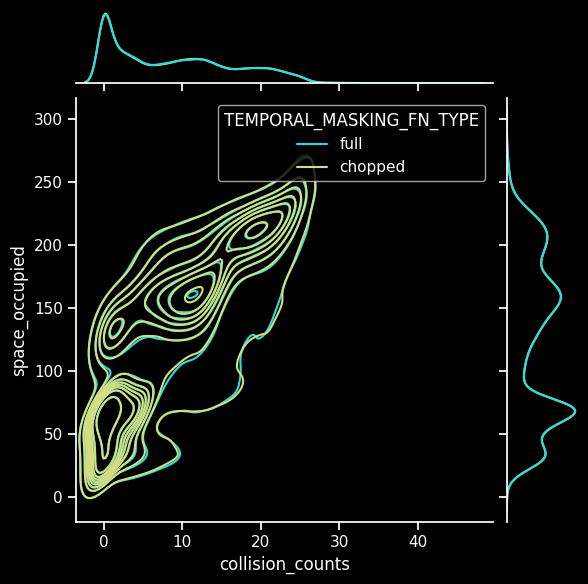

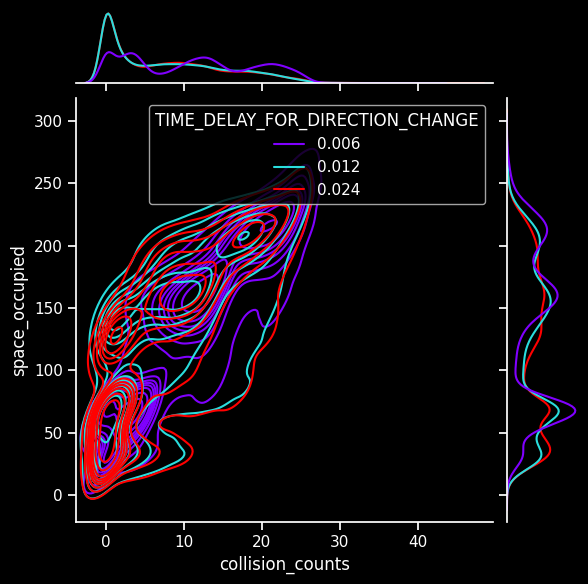

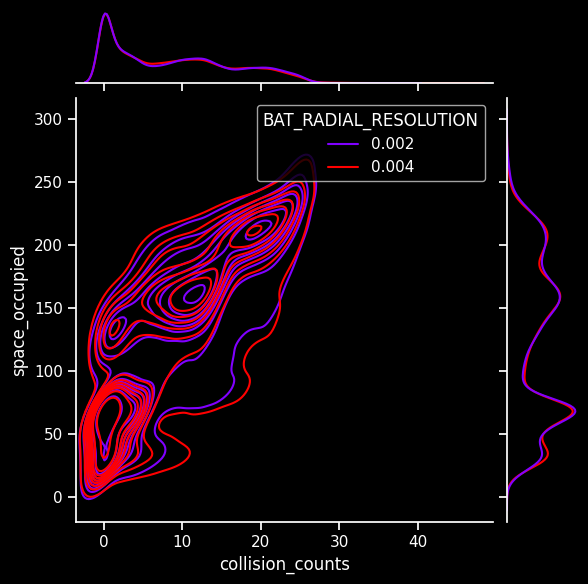

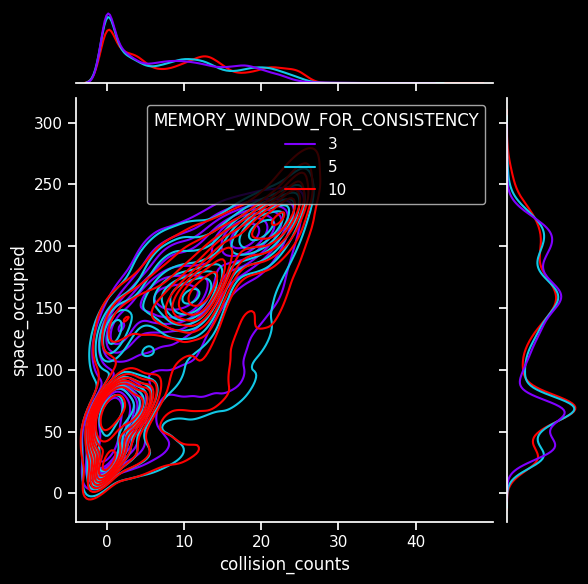

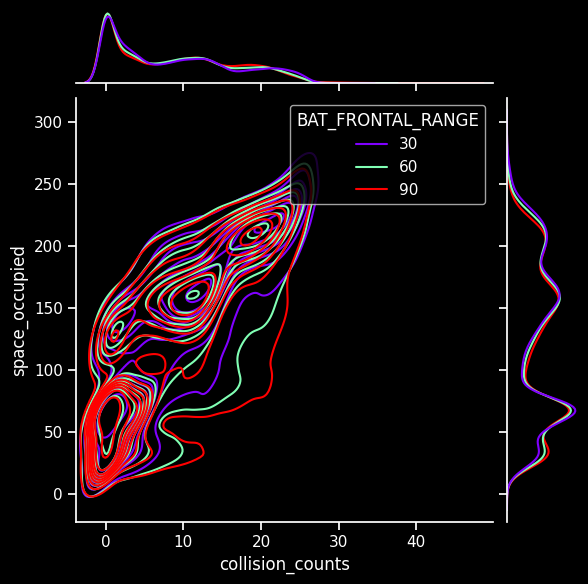

In [21]:
plt.figure(figsize=(25,20))
for i, param in enumerate(varying_params):
        # plt.subplot(3,number_of_subfigs,i+1)
        sns.jointplot(df_overall_model, x="collision_counts", y="space_occupied", kind="kde", palette="rainbow", hue=param)
        plt.show()

In [9]:
def center_df(df):
    centered_df=(df-df.mean())/df.std()
    return centered_df

In [10]:
varying_params = np.array([
    "CALL_DURATION",
    "CALL_RATE_FAST",
    "HEARING_THRESHOLD",
    "CALL_DIRECTIONALITY",
    "TEMPORAL_MASKING_FN_TYPE_ONE_HOT",
    "TIME_DELAY_FOR_DIRECTION_CHANGE",
    "BAT_RADIAL_RESOLUTION",
    "MEMORY_WINDOW_FOR_CONSISTENCY",
    "BAT_FRONTAL_RANGE",
])
df_overall_model["TEMPORAL_MASKING_FN_TYPE_ONE_HOT"] = [1 if i=="full" else 0 for i in df_overall_model["TEMPORAL_MASKING_FN_TYPE"]] 

In [11]:
store_regression_coef = []
store_hue_label = []
store_param_label = []
for bat_speed in bat_speeds:
    subset_of_df = df_overall_model[df_overall_model["BAT_SPEED"]==bat_speed]
    predictors = subset_of_df[varying_params]
    predictors = center_df(predictors)
    response_variables = subset_of_df["collision_counts"]

    regression = linear_model.LinearRegression()
    regression.fit(predictors, response_variables)
    store_regression_coef.extend(regression.coef_)
    store_hue_label.extend([bat_speed]*len(varying_params))
    store_param_label.extend(varying_params)

NameError: name 'bat_speeds' is not defined

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

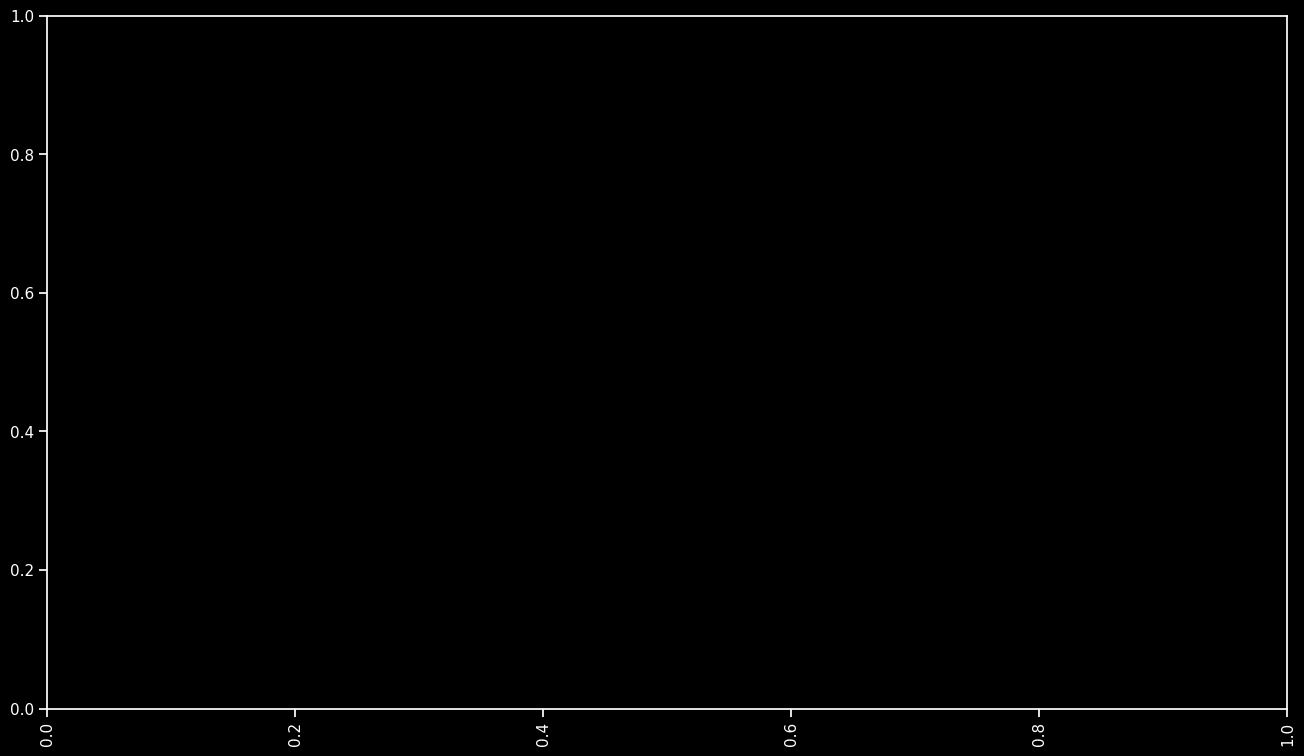

In [12]:
plt.figure(figsize=(16,9))
sns.barplot(x=store_param_label, y=store_regression_coef, hue=store_hue_label, palette="viridis")
plt.xticks(rotation=90)

In [14]:
varying_params = np.array([
    "BAT_SPEED",
    "CALL_DURATION",
    "CALL_RATE_FAST",
    "HEARING_THRESHOLD",
    "CALL_DIRECTIONALITY",
    "TEMPORAL_MASKING_FN_TYPE_ONE_HOT",
    "TIME_DELAY_FOR_DIRECTION_CHANGE",
    "BAT_RADIAL_RESOLUTION",
    "MEMORY_WINDOW_FOR_CONSISTENCY",
    "BAT_FRONTAL_RANGE",
])

In [15]:
store_regression_coef = []
store_hue_label = []
store_param_label = []

centered_df = df_overall_model.copy()
predictors = centered_df[varying_params]
centered_df[varying_params] = center_df(predictors)
response_variables = centered_df["collision_counts"]

# regression = linear_model.LinearRegression()
# regression.fit(predictors, response_variables)
# store_regression_coef.extend(regression.coef_)
# store_hue_label.extend([bat_speed]*len(varying_params))
# store_param_label.extend(varying_params)
centered_df
df_overall_model

,Unnamed: 0.1,Unnamed: 0,space_occupied,collision_counts,collision_rate,calling_effort,iteration_label,SOUND_SPEED,SIM_DURATION,TIME_STEP,...,TIME_DELAY_THRESHOLD_FOR_REPULSION,BEHAVIOUR_RULE,CONTROLLER_TYPE,STORE_HEARING,JAMMER_RESOLUTION,TEMPORAL_MASKING_FN_TYPE,OUTPUT_DIR_FOR_SIMULATION,PARAM_LABEL,TEMPORAL_MASKING_FN_TYPE_ONE_HOT,identifier
0,0,0,66,1,0.008500,300,iteration_number_0,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
1,1,1,67,0,0.000000,300,iteration_number_1,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
2,2,2,60,1,0.008633,299,iteration_number_2,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
3,3,3,69,0,0.000000,301,iteration_number_3,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
4,4,4,67,0,0.000000,299,iteration_number_4,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155515,15,15,183,18,0.040867,322,iteration_number_15,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155516,16,16,147,29,0.057767,320,iteration_number_16,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155517,17,17,177,17,0.047533,321,iteration_number_17,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155518,18,18,166,17,0.043467,322,iteration_number_18,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment


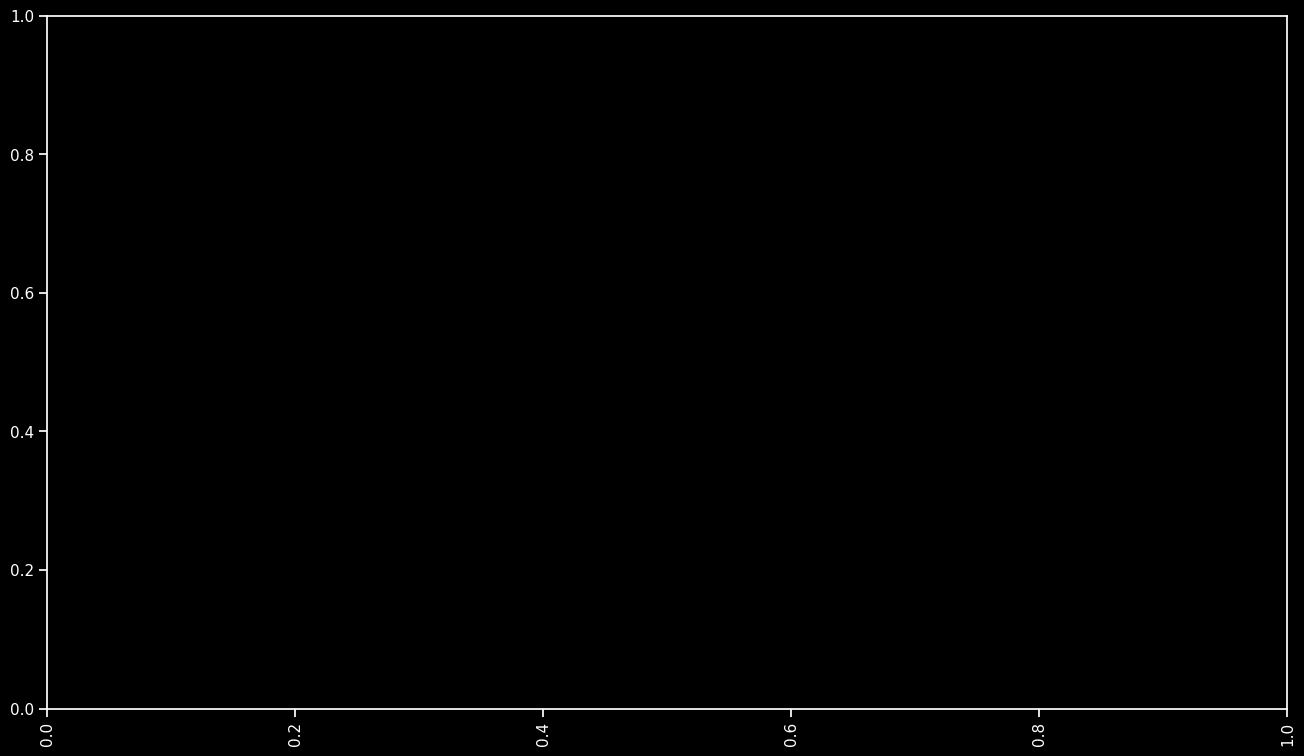

In [16]:
plt.figure(figsize=(16,9))
sns.barplot(x=store_param_label, y=store_regression_coef)
plt.xticks(rotation=90)
plt.show()

In [17]:
df_overall_model

,Unnamed: 0.1,Unnamed: 0,space_occupied,collision_counts,collision_rate,calling_effort,iteration_label,SOUND_SPEED,SIM_DURATION,TIME_STEP,...,TIME_DELAY_THRESHOLD_FOR_REPULSION,BEHAVIOUR_RULE,CONTROLLER_TYPE,STORE_HEARING,JAMMER_RESOLUTION,TEMPORAL_MASKING_FN_TYPE,OUTPUT_DIR_FOR_SIMULATION,PARAM_LABEL,TEMPORAL_MASKING_FN_TYPE_ONE_HOT,identifier
0,0,0,66,1,0.008500,300,iteration_number_0,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
1,1,1,67,0,0.000000,300,iteration_number_1,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
2,2,2,60,1,0.008633,299,iteration_number_2,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
3,3,3,69,0,0.000000,301,iteration_number_3,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
4,4,4,67,0,0.000000,299,iteration_number_4,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155515,15,15,183,18,0.040867,322,iteration_number_15,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155516,16,16,147,29,0.057767,320,iteration_number_16,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155517,17,17,177,17,0.047533,321,iteration_number_17,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155518,18,18,166,17,0.043467,322,iteration_number_18,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment


In [18]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

Check the variance of the response variable

This deicdes if to use negative binomial or poisson

Mean of collision counts : 8.78542952674897
Variance of collision counts : 59.63181445028044


Text(0, 0.5, 'simulation counts')

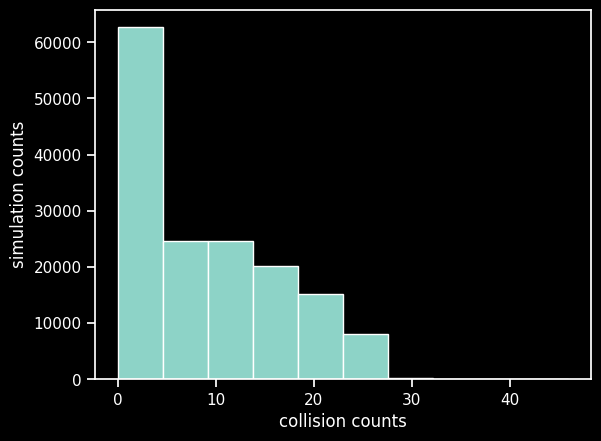

In [19]:
df_overall_model["collision_counts"]
print(f"Mean of collision counts : {np.mean(df_overall_model["collision_counts"])}")
print(f"Variance of collision counts : {np.var(df_overall_model["collision_counts"])}")
plt.hist(df_overall_model["collision_counts"])
plt.xlabel("collision counts")
plt.ylabel("simulation counts")

In [20]:
mean = np.mean(df_overall_model["collision_counts"])
var = np.var(df_overall_model["collision_counts"])
alpha = var/(mean**2) - (1/mean)
alpha

np.float64(0.6587704076401188)

Variance is much larger than mean, hence negative bionmial is a better model

In [21]:
model_nb =smf.negativebinomial(
    formula= "collision_counts ~ BAT_SPEED + CALL_DURATION + CALL_RATE_FAST + HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT + TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION + MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE",
    data= df_overall_model,
    # family=sm.families.NegativeBinomial(alpha=0.65)
).fit()
print(model_nb.summary())

/home/adityamoger/anaconda3/envs/cocktail_3_dynamic_model/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/home/adityamoger/anaconda3/envs/cocktail_3_dynamic_model/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/home/adityamoger/anaconda3/envs/cocktail_3_dynamic_model/lib/python3.12/site-packages/scipy/optimize/_optimize.py:1313: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/home/adityamoger/anaconda3/envs/cocktail_3_dynamic_model/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

         Current function value: 2.788901
         Iterations: 35
         Function evaluations: 44
         Gradient evaluations: 44
                     NegativeBinomial Regression Results                      
Dep. Variable:       collision_counts   No. Observations:               155520
Model:               NegativeBinomial   Df Residuals:                   155509
Method:                           MLE   Df Model:                           10
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                  0.1339
Time:                        16:47:10   Log-Likelihood:            -4.3373e+05
converged:                      False   LL-Null:                   -5.0079e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                       

In [34]:
model_nb_centered =smf.negativebinomial(
    formula= "collision_counts ~ BAT_SPEED + CALL_DURATION + CALL_RATE_FAST + HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT + TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION + MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE",
    data= centered_df,
    # family=sm.families.NegativeBinomial(alpha=0.65)
).fit()
print(model_nb_centered.summary())

Optimization terminated successfully.
         Current function value: 2.788496
         Iterations: 13
         Function evaluations: 15
         Gradient evaluations: 15
                     NegativeBinomial Regression Results                      
Dep. Variable:       collision_counts   No. Observations:               155520
Model:               NegativeBinomial   Df Residuals:                   155509
Method:                           MLE   Df Model:                           10
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                  0.1340
Time:                        16:54:59   Log-Likelihood:            -4.3367e+05
converged:                       True   LL-Null:                   -5.0079e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [37]:
model_nb_centered.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                            Results: NegativeBinomial
=================================================================================
Model:                   NegativeBinomial      Pseudo R-squared:      0.134      
Dependent Variable:      collision_counts      AIC:                   867357.8622
Date:                    2026-03-11 17:04      BIC:                   867477.3165
No. Observations:        155520                Log-Likelihood:        -4.3367e+05
Df Model:                10                    LL-Null:               -5.0079e+05
Df Residuals:            155509                LLR p-value:           0.0000     
Converged:               1.0000                Scale:                 1.0000     
Method:                  MLE                                                     
---------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                         1.8130   0.0018 988.4564 0.0000  1.8094  1.8166
BAT_SPEED                         0.9130   0.0020 457.9947 0.0000  0.9091  0.9169
CALL_DURATION                     0.0402   0.0017  23.0100 0.0000  0.0368  0.0437
CALL_RATE_FAST                   -0.0640   0.0017 -36.6502 0.0000 -0.0674 -0.0605
HEARING_THRESHOLD                 0.0349   0.0017  20.5515 0.0000  0.0316  0.0383
CALL_DIRECTIONALITY               0.0128   0.0017   7.3161 0.0000  0.0093  0.0162
TEMPORAL_MASKING_FN_TYPE_ONE_HOT  0.0011   0.0017   0.6190 0.5359 -0.0023  0.0045
TIME_DELAY_FOR_DIRECTION_CHANGE  -0.1477   0.0017 -85.6865 0.0000 -0.1510 -0.1443
BAT_RADIAL_RESOLUTION             0.0061   0.0017   3.5099 0.0004  0.0027  0.0095
MEMORY_WINDOW_FOR_CONSISTENCY     0.0903   0.0017  51.6903 0.0000  0.0868  0.0937
BAT_FRONTAL_RANGE                 0.0294   0.0017  16.8365 0.0000  0.0260  0.0328
alpha                             0.2945   0.0021 141.9224 0.0000  0.2904  0.2985
=================================================================================

"""

CHECK to ensure dispersion is high

In [38]:
model_poisson_centered =smf.glm(
    formula= "collision_counts ~ BAT_SPEED + CALL_DURATION + CALL_RATE_FAST + HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT + TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION + MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE",
    data= centered_df,
    family=sm.families.Poisson()
).fit()
print(model_poisson_centered.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       collision_counts   No. Observations:               155520
Model:                            GLM   Df Residuals:                   155509
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.7780e+05
Date:                Wed, 11 Mar 2026   Deviance:                   4.6258e+05
Time:                        17:14:24   Pearson chi2:                 4.74e+05
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9928
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [70]:
pearson_poisson = model_poisson_centered.resid_pearson
dispersion = sum(pearson_poisson**2)/ model_poisson_centered.df_resid
dispersion

np.float64(3.047919038162193)

dispersion greater than 2 hence using negative binomial for further analysis.

In [40]:
model_nb_centered =smf.negativebinomial(
    formula= "collision_counts ~ BAT_SPEED + CALL_DURATION + CALL_RATE_FAST + HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT + TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION + MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE",
    data= centered_df,
    # family=sm.families.NegativeBinomial(alpha=0.65)
).fit()
print(model_nb_centered.summary())

Optimization terminated successfully.
         Current function value: 2.788496
         Iterations: 13
         Function evaluations: 15
         Gradient evaluations: 15
                     NegativeBinomial Regression Results                      
Dep. Variable:       collision_counts   No. Observations:               155520
Model:               NegativeBinomial   Df Residuals:                   155509
Method:                           MLE   Df Model:                           10
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                  0.1340
Time:                        17:14:29   Log-Likelihood:            -4.3367e+05
converged:                       True   LL-Null:                   -5.0079e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

Text(0.5, 0, 'predicted y')

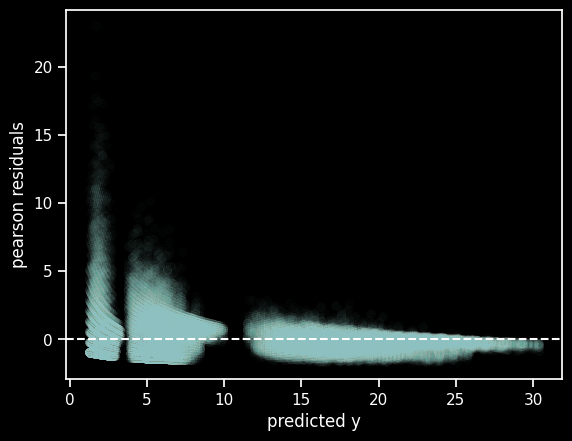

In [41]:
model_nb_centered.params["alpha"]
y_hat = model_nb_centered.predict(centered_df)
pearson_residuals_nb_centered = model_nb_centered.resid_pearson
centered_df["pearson_resid_nbinom"] = pearson_residuals_nb_centered
sns.scatterplot(x=y_hat, y=pearson_residuals_nb_centered, alpha=0.02)
plt.axhline(0, ls="--")
plt.ylabel("pearson residuals")
plt.xlabel("predicted y")

<Axes: xlabel='None', ylabel='pearson_resid_nbinom'>

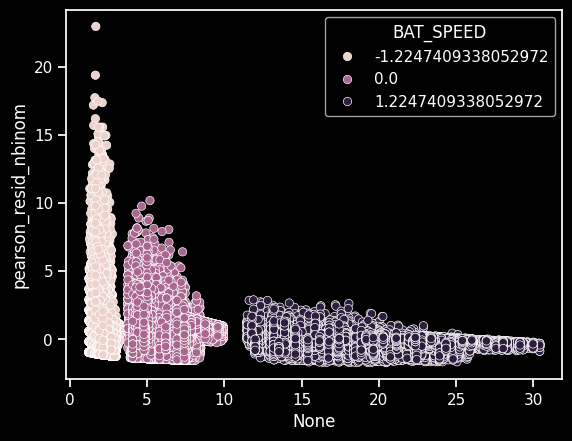

In [42]:
sns.scatterplot(data=centered_df, x=y_hat, y="pearson_resid_nbinom", hue="BAT_SPEED")

In [43]:
centered_df_speed_1 = centered_df[centered_df["BAT_SPEED"]<0]
centered_df_speed_3 = centered_df[centered_df["BAT_SPEED"]==0]
centered_df_speed_5 = centered_df[centered_df["BAT_SPEED"]>0]
centered_df_speed_1

,Unnamed: 0.1,Unnamed: 0,space_occupied,collision_counts,collision_rate,calling_effort,iteration_label,SOUND_SPEED,SIM_DURATION,TIME_STEP,...,BEHAVIOUR_RULE,CONTROLLER_TYPE,STORE_HEARING,JAMMER_RESOLUTION,TEMPORAL_MASKING_FN_TYPE,OUTPUT_DIR_FOR_SIMULATION,PARAM_LABEL,TEMPORAL_MASKING_FN_TYPE_ONE_HOT,identifier,pearson_resid_nbinom
0,0,0,66,1,0.008500,300,iteration_number_0,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,0.999997,treatment,-0.441396
1,1,1,67,0,0.000000,300,iteration_number_1,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,0.999997,treatment,-1.065799
2,2,2,60,1,0.008633,299,iteration_number_2,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,0.999997,treatment,-0.441396
3,3,3,69,0,0.000000,301,iteration_number_3,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,0.999997,treatment,-1.065799
4,4,4,67,0,0.000000,299,iteration_number_4,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,0.999997,treatment,-1.065799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155475,15,15,35,2,0.020233,299,iteration_number_15,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2/,paramset_2,0.999997,treatment,-0.073819
155476,16,16,24,0,0.000000,298,iteration_number_16,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2/,paramset_2,0.999997,treatment,-1.145378
155477,17,17,38,6,0.105367,300,iteration_number_17,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2/,paramset_2,0.999997,treatment,2.069300
155478,18,18,34,0,0.000000,301,iteration_number_18,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2/,paramset_2,0.999997,treatment,-1.145378


In [44]:
model_nb_centered_speed_1 =smf.negativebinomial(
    formula= "collision_counts ~ CALL_DURATION + CALL_RATE_FAST + HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT + TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION + MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE",
    data= centered_df_speed_1,
    # family=sm.families.NegativeBinomial(alpha=0.65)
).fit()
print(model_nb_centered_speed_1.summary2())

Optimization terminated successfully.
         Current function value: 1.556587
         Iterations: 11
         Function evaluations: 12
         Gradient evaluations: 12
                            Results: NegativeBinomial
Model:                   NegativeBinomial      Pseudo R-squared:      0.037      
Dependent Variable:      collision_counts      AIC:                   161408.9827
Date:                    2026-03-11 17:14      BIC:                   161506.3978
No. Observations:        51840                 Log-Likelihood:        -80693.    
Df Model:                9                     LL-Null:               -83824.    
Df Residuals:            51830                 LLR p-value:           0.0000     
Converged:               1.0000                Scale:                 1.0000     
Method:                  MLE                                                     
---------------------------------------------------------------------------------
                                  Co

Text(0.5, 0, 'predicted y')

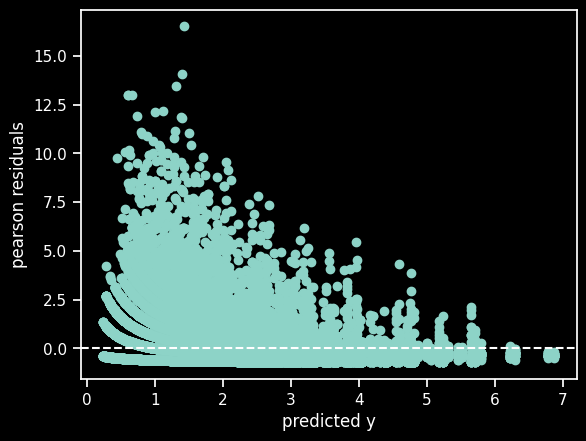

In [45]:
model_nb_centered.params["alpha"]
y_hat = model_nb_centered_speed_1.predict(centered_df_speed_1)
pearson_residuals_nb_centered = model_nb_centered_speed_1.resid_pearson

plt.scatter(y_hat, pearson_residuals_nb_centered)
plt.axhline(0, ls="--")
plt.ylabel("pearson residuals")
plt.xlabel("predicted y")

In [46]:
model_nb_centered_speed_3 =smf.negativebinomial(
    formula= "collision_counts ~ CALL_DURATION + CALL_RATE_FAST + HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT + TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION + MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE",
    data= centered_df_speed_3,
    # family=sm.families.NegativeBinomial(alpha=0.65)
).fit()
print(model_nb_centered_speed_3.summary2())

Optimization terminated successfully.
         Current function value: 2.992750
         Iterations: 12
         Function evaluations: 15
         Gradient evaluations: 15
                            Results: NegativeBinomial
Model:                   NegativeBinomial      Pseudo R-squared:      0.017      
Dependent Variable:      collision_counts      AIC:                   310310.2821
Date:                    2026-03-11 17:15      BIC:                   310407.6972
No. Observations:        51840                 Log-Likelihood:        -1.5514e+05
Df Model:                9                     LL-Null:               -1.5777e+05
Df Residuals:            51830                 LLR p-value:           0.0000     
Converged:               1.0000                Scale:                 1.0000     
Method:                  MLE                                                     
---------------------------------------------------------------------------------
                                  Co

Text(0.5, 0, 'predicted y')

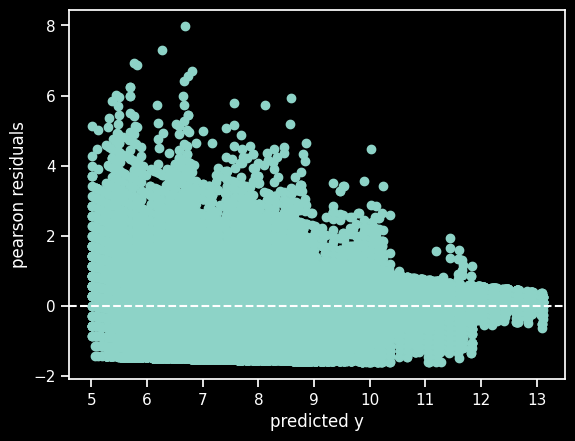

In [47]:
model_nb_centered.params["alpha"]
y_hat = model_nb_centered_speed_3.predict(centered_df_speed_3)
pearson_residuals_nb_centered = model_nb_centered_speed_3.resid_pearson

plt.scatter(y_hat, pearson_residuals_nb_centered)
plt.axhline(0, ls="--")
plt.ylabel("pearson residuals")
plt.xlabel("predicted y")

In [48]:
model_nb_centered_speed_5 =smf.negativebinomial(
    formula= "collision_counts ~ CALL_DURATION + CALL_RATE_FAST + HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT + TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION + MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE",
    data= centered_df_speed_5,
    # family=sm.families.NegativeBinomial(alpha=0.65)
).fit()
print(model_nb_centered_speed_5.summary2())

Optimization terminated successfully.
         Current function value: 3.081448
         Iterations: 16
         Function evaluations: 24
         Gradient evaluations: 24
                            Results: NegativeBinomial
Model:                    NegativeBinomial      Pseudo R-squared:      0.049      
Dependent Variable:       collision_counts      AIC:                   319506.5346
Date:                     2026-03-11 17:15      BIC:                   319603.9497
No. Observations:         51840                 Log-Likelihood:        -1.5974e+05
Df Model:                 9                     LL-Null:               -1.6802e+05
Df Residuals:             51830                 LLR p-value:           0.0000     
Converged:                1.0000                Scale:                 1.0000     
Method:                   MLE                                                     
----------------------------------------------------------------------------------
                           

Text(0.5, 0, 'predicted y')

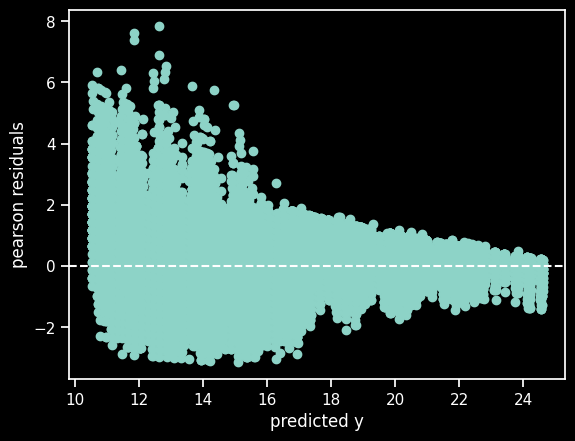

In [49]:
model_nb_centered.params["alpha"]
y_hat = model_nb_centered_speed_5.predict(centered_df_speed_5)
pearson_residuals_nb_centered = model_nb_centered_speed_5.resid_pearson

plt.scatter(y_hat, pearson_residuals_nb_centered)
plt.axhline(0, ls="--")
plt.ylabel("pearson residuals")
plt.xlabel("predicted y")

In [60]:
model_nb_centered.pvalues

Intercept                            0.000000e+00
BAT_SPEED                            0.000000e+00
CALL_DURATION                       3.699499e-117
CALL_RATE_FAST                      4.538896e-294
HEARING_THRESHOLD                    7.464457e-94
CALL_DIRECTIONALITY                  2.553395e-13
TEMPORAL_MASKING_FN_TYPE_ONE_HOT     5.359089e-01
TIME_DELAY_FOR_DIRECTION_CHANGE      0.000000e+00
BAT_RADIAL_RESOLUTION                4.482027e-04
MEMORY_WINDOW_FOR_CONSISTENCY        0.000000e+00
BAT_FRONTAL_RANGE                    1.317849e-63
alpha                                0.000000e+00
dtype: float64

In [64]:
model_nb_centered.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                            Results: NegativeBinomial
=================================================================================
Model:                   NegativeBinomial      Pseudo R-squared:      0.134      
Dependent Variable:      collision_counts      AIC:                   867357.8622
Date:                    2026-03-11 17:39      BIC:                   867477.3165
No. Observations:        155520                Log-Likelihood:        -4.3367e+05
Df Model:                10                    LL-Null:               -5.0079e+05
Df Residuals:            155509                LLR p-value:           0.0000     
Converged:               1.0000                Scale:                 1.0000     
Method:                  MLE                                                     
---------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                         1.8130   0.0018 988.4564 0.0000  1.8094  1.8166
BAT_SPEED                         0.9130   0.0020 457.9947 0.0000  0.9091  0.9169
CALL_DURATION                     0.0402   0.0017  23.0100 0.0000  0.0368  0.0437
CALL_RATE_FAST                   -0.0640   0.0017 -36.6502 0.0000 -0.0674 -0.0605
HEARING_THRESHOLD                 0.0349   0.0017  20.5515 0.0000  0.0316  0.0383
CALL_DIRECTIONALITY               0.0128   0.0017   7.3161 0.0000  0.0093  0.0162
TEMPORAL_MASKING_FN_TYPE_ONE_HOT  0.0011   0.0017   0.6190 0.5359 -0.0023  0.0045
TIME_DELAY_FOR_DIRECTION_CHANGE  -0.1477   0.0017 -85.6865 0.0000 -0.1510 -0.1443
BAT_RADIAL_RESOLUTION             0.0061   0.0017   3.5099 0.0004  0.0027  0.0095
MEMORY_WINDOW_FOR_CONSISTENCY     0.0903   0.0017  51.6903 0.0000  0.0868  0.0937
BAT_FRONTAL_RANGE                 0.0294   0.0017  16.8365 0.0000  0.0260  0.0328
alpha                             0.2945   0.0021 141.9224 0.0000  0.2904  0.2985
=================================================================================

"""

In [67]:
np.exp(model_nb_centered.params)

Intercept                           6.128655
BAT_SPEED                           2.491767
CALL_DURATION                       1.041066
CALL_RATE_FAST                      0.938033
HEARING_THRESHOLD                   1.035554
CALL_DIRECTIONALITY                 1.012846
TEMPORAL_MASKING_FN_TYPE_ONE_HOT    1.001080
TIME_DELAY_FOR_DIRECTION_CHANGE     0.862723
BAT_RADIAL_RESOLUTION               1.006147
MEMORY_WINDOW_FOR_CONSISTENCY       1.094464
BAT_FRONTAL_RANGE                   1.029808
alpha                               1.342432
dtype: float64

In [73]:
model_glm_negative_binom_centered =smf.glm(
    formula= "collision_counts ~ BAT_SPEED + CALL_DURATION + CALL_RATE_FAST + HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT + TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION + MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE",
    data= centered_df,
    family=sm.families.NegativeBinomial(alpha=dispersion)
).fit()
model_glm_negative_binom_centered.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Generalized linear model
=================================================================================
Model:                   GLM                   AIC:                 1006076.9285 
Link Function:           Log                   BIC:                 -1803353.7820
Dependent Variable:      collision_counts      Log-Likelihood:      -5.0303e+05  
Date:                    2026-03-11 17:51      LL-Null:             -5.2187e+05  
No. Observations:        155520                Deviance:            55683.       
Df Model:                10                    Pearson chi2:        4.41e+04     
Df Residuals:            155509                Scale:               1.0000       
Method:                  IRLS                                                    
---------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                         1.7835   0.0046 386.2841 0.0000  1.7745  1.7926
BAT_SPEED                         0.9998   0.0046 215.1939 0.0000  0.9907  1.0089
CALL_DURATION                     0.0638   0.0046  13.8416 0.0000  0.0547  0.0728
CALL_RATE_FAST                   -0.0695   0.0046 -15.0943 0.0000 -0.0786 -0.0605
HEARING_THRESHOLD                -0.0153   0.0046  -3.3299 0.0009 -0.0244 -0.0063
CALL_DIRECTIONALITY               0.0191   0.0046   4.1553 0.0000  0.0101  0.0282
TEMPORAL_MASKING_FN_TYPE_ONE_HOT  0.0018   0.0046   0.3998 0.6893 -0.0072  0.0109
TIME_DELAY_FOR_DIRECTION_CHANGE  -0.1541   0.0046 -33.3682 0.0000 -0.1631 -0.1450
BAT_RADIAL_RESOLUTION             0.0168   0.0046   3.6389 0.0003  0.0077  0.0258
MEMORY_WINDOW_FOR_CONSISTENCY     0.1164   0.0046  25.3067 0.0000  0.1074  0.1254
BAT_FRONTAL_RANGE                 0.0377   0.0046   8.1751 0.0000  0.0286  0.0467
=================================================================================

"""

In [75]:
np.exp(model_glm_negative_binom_centered.params)

Intercept                           5.950676
BAT_SPEED                           2.717818
CALL_DURATION                       1.065846
CALL_RATE_FAST                      0.932822
HEARING_THRESHOLD                   0.984776
CALL_DIRECTIONALITY                 1.019328
TEMPORAL_MASKING_FN_TYPE_ONE_HOT    1.001843
TIME_DELAY_FOR_DIRECTION_CHANGE     0.857191
BAT_RADIAL_RESOLUTION               1.016906
MEMORY_WINDOW_FOR_CONSISTENCY       1.123417
BAT_FRONTAL_RANGE                   1.038381
dtype: float64

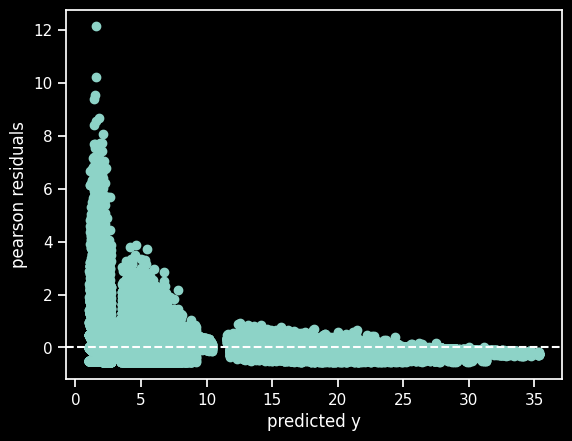

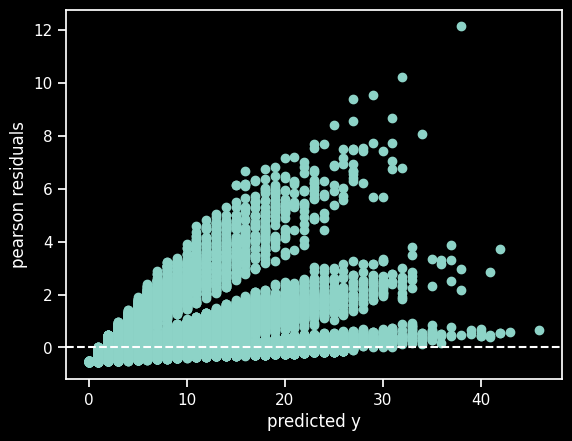

In [79]:
model_nb_centered.params["alpha"]
y_hat = model_glm_negative_binom_centered.predict(centered_df)
pearson_residuals_nb_centered = model_glm_negative_binom_centered.resid_pearson

plt.scatter(y_hat, pearson_residuals_nb_centered)
plt.axhline(0, ls="--")
plt.ylabel("pearson residuals")
plt.xlabel("predicted y")
plt.show()

plt.scatter(centered_df["collision_counts"], pearson_residuals_nb_centered)
plt.axhline(0, ls="--")
plt.ylabel("pearson residuals")
plt.xlabel("predicted y")
plt.show()

In [96]:
varying_params = np.array([
    "BAT_SPEED",
    "CALL_DURATION",
    "CALL_RATE_FAST",
    "HEARING_THRESHOLD",
    "CALL_DIRECTIONALITY",
    "TEMPORAL_MASKING_FN_TYPE_ONE_HOT",
    "TIME_DELAY_FOR_DIRECTION_CHANGE",
    "BAT_RADIAL_RESOLUTION",
    "MEMORY_WINDOW_FOR_CONSISTENCY",
    "BAT_FRONTAL_RANGE",
])
Z = df_overall_model[varying_params]
X = df_overall_model["space_occupied"]
Y = df_overall_model["collision_counts"]
X=  df_overall_model[["collision_counts", "space_occupied"]]

In [86]:
from sklearn.cluster import DBSCAN

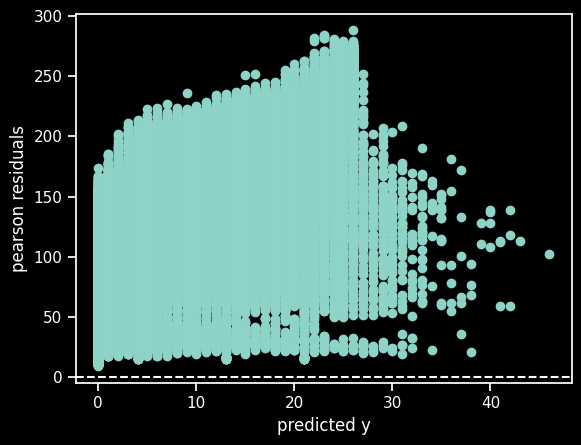

In [99]:
plt.scatter(df_overall_model["collision_counts"], df_overall_model["space_occupied"])
plt.axhline(0, ls="--")
plt.ylabel("pearson residuals")
plt.xlabel("predicted y")
plt.show()

In [98]:
dbscan = DBSCAN()
clusters = dbscan.fit_predict(X)
clusters

array([   0,    1,    2, ..., 2215, 2235, 1038], shape=(155520,))

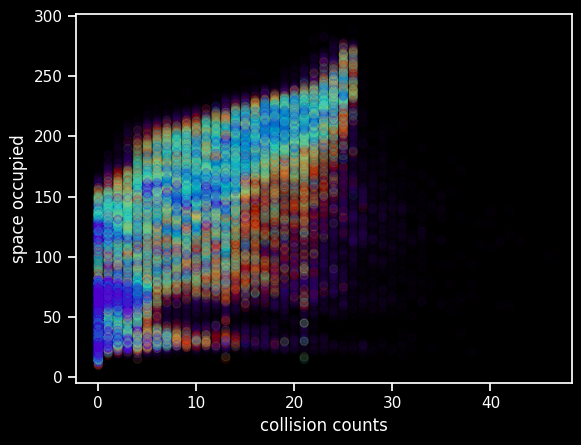

In [109]:
plt.scatter(df_overall_model["collision_counts"], df_overall_model["space_occupied"], c=clusters, alpha=0.02, cmap="rainbow")

plt.ylabel("space occupied")
plt.xlabel("collision counts")
plt.show()

In [117]:
np.unique(clusters)

array([  -1,    0,    1, ..., 3963, 3964, 3965], shape=(3967,))

In [114]:
clusters_with_zero_collision = clusters[df_overall_model["collision_counts"] == 0]

In [115]:
np.unique(clusters_with_zero_collision)

array([  -1,    1,    3,    6,    7,    8,    9,   10,   11,   12,   16,
         17,   18,   21,   23,   24,   26,   27,   28,   29,   30,   33,
         38,   39,   45,   46,   90,   98,  102,  103,  104,  105,  106,
        107,  108,  109,  110,  111,  112,  113,  114,  133,  134,  135,
        137,  140,  154,  171,  205,  257,  259,  261,  278,  299,  300,
        302,  325,  327,  329,  333,  337,  340,  341,  342,  343,  347,
        349,  372,  453,  454,  455,  458,  459,  658,  660,  661,  662,
        663,  665,  667,  705,  706,  707,  708,  709,  882,  890,  911,
        916,  918,  924, 1002, 1003, 1048, 1054, 1075, 1080, 1081, 1082,
       1143, 1158, 1232, 1236, 1237, 1239, 1242, 1259, 1294, 1296, 1297,
       1302, 1405, 1419, 1462, 1472, 1497, 1499, 1630, 1669, 1799, 1826,
       1900, 1918, 1968, 1969, 1971, 1973, 1974, 1976, 2011, 2012, 2436,
       2603, 2892, 3037, 3104, 3105, 3168, 3257, 3270, 3304, 3327, 3350,
       3452, 3453, 3462, 3700, 3759, 3768, 3850])

In [120]:
modified_cluster_labels = [i if i in clusters_with_zero_collision else -2 for i in clusters]

/tmp/ipykernel_351900/346247624.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(modified_cluster_labels, df_overall_model["space_occupied"], cmap="rainbow")


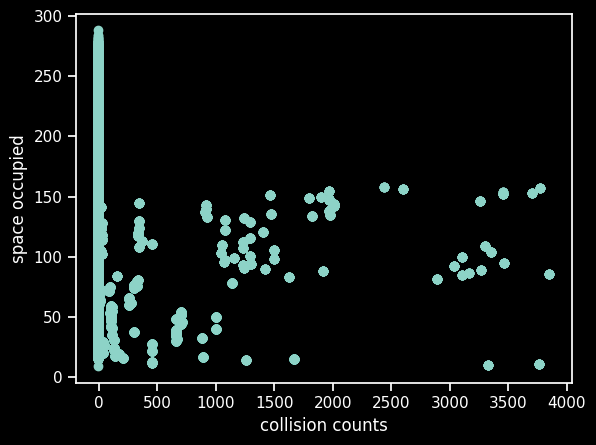

In [126]:
plt.scatter(modified_cluster_labels, df_overall_model["space_occupied"], cmap="rainbow")

plt.ylabel("space occupied")
plt.xlabel("collision counts")
# plt.xlim(-1,2)
plt.show()

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x71eabb459190>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x71eabb9e5160>,
 'cmins': <matplotlib.collections.LineCollection at 0x71eabb0b1220>,
 'cbars': <matplotlib.collections.LineCollection at 0x71eac3cebc50>}

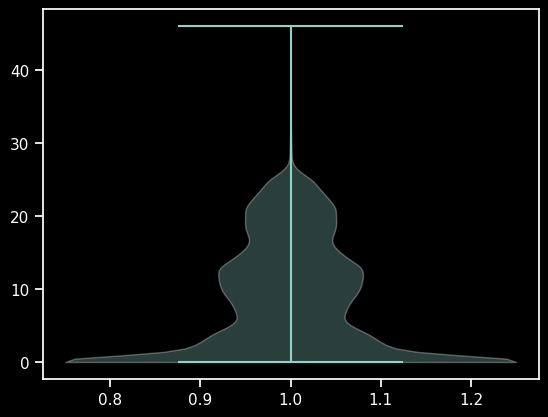

In [128]:
plt.violinplot(df_overall_model["collision_counts"])

In [130]:
np.max(df_overall_model["collision_counts"])
0.05*46

2.3000000000000003

In [133]:
np.mean(df_overall_model["space_occupied"]), np.var(df_overall_model["space_occupied"])

(np.float64(126.69573688271605), np.float64(4060.528700961634))

# AI SHIT

In [171]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.genmod.families import NegativeBinomial
from scipy.special import logit, expit

In [149]:
df = centered_df.copy()

formula = """
collision_counts ~ BAT_SPEED + CALL_DURATION + CALL_RATE_FAST +
HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT +
TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION +
MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE
"""


In [137]:
poisson_model = smf.glm(formula=formula, data=df, family=sm.families.Poisson()).fit()

# Calculate dispersion parameter
pearson_resid = poisson_model.resid_pearson
dispersion = np.sum(pearson_resid**2) / poisson_model.df_resid
alpha = 1/dispersion  # Initial estimate for Negative Binomial alpha

print(f"Estimated dispersion: {dispersion:.4f}")
print(f"Initial alpha estimate: {alpha:.4f}")

Estimated dispersion: 3.0479
Initial alpha estimate: 0.3281


In [143]:
model_nb = smf.glm(
    formula=formula,
    data=df,
    family=NegativeBinomial(alpha=alpha)
).fit()

# Print summary
print("NEGATIVE BINOMIAL MODEL (COLLISION COUNTS)")
print(model_nb.summary2())
print(f"\nFinal alpha parameter: {model_nb.family.alpha:.4f}")

NEGATIVE BINOMIAL MODEL (COLLISION COUNTS)
                        Results: Generalized linear model
Model:                   GLM                   AIC:                 867595.6179  
Link Function:           Log                   BIC:                 -1660560.1412
Dependent Variable:      collision_counts      Log-Likelihood:      -4.3379e+05  
Date:                    2026-03-11 20:26      LL-Null:             -5.5072e+05  
No. Observations:        155520                Deviance:            1.9848e+05   
Df Model:                10                    Pearson chi2:        2.00e+05     
Df Residuals:            155509                Scale:               1.0000       
Method:                  IRLS                                                    
---------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------------------

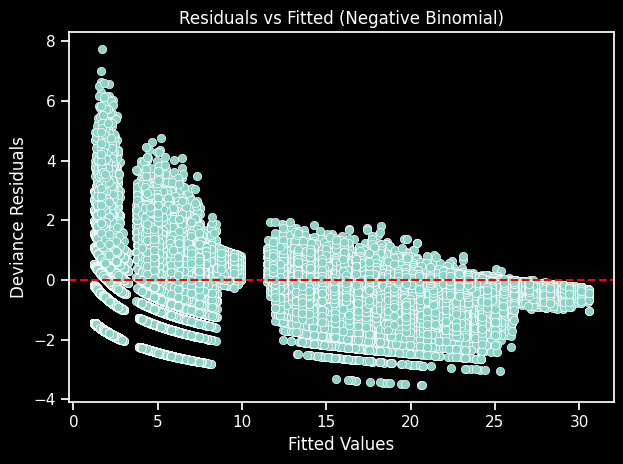

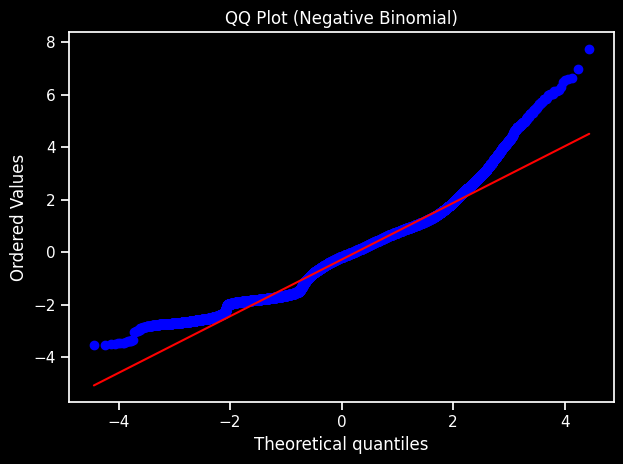

In [144]:
plt.figure()
sns.scatterplot(x=model_nb.fittedvalues, y=model_nb.resid_deviance)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Deviance Residuals")
plt.title("Residuals vs Fitted (Negative Binomial)")
plt.tight_layout()
plt.show()

# QQ Plot
plt.figure()
stats.probplot(model_nb.resid_deviance, dist="norm", plot=plt)
plt.title("QQ Plot (Negative Binomial)")
plt.tight_layout()
plt.show()

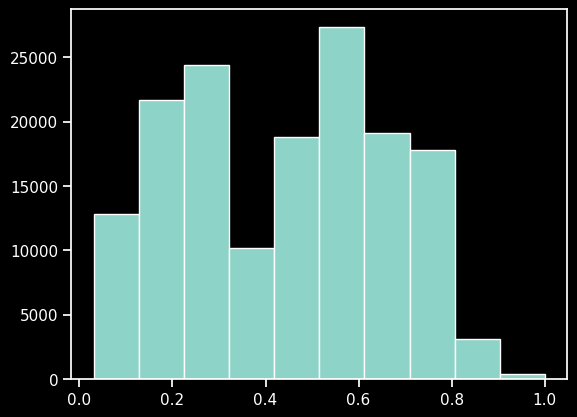

0         288
1         288
2         288
3         288
4         288
         ... 
155515    288
155516    288
155517    288
155518    288
155519    288
Name: space_occupied_N, Length: 155520, dtype: int64

In [165]:
df['space_occupied_norm'] = df['space_occupied'] / np.max(df["space_occupied"])  # Normalized space
df['space_occupied_N'] = np.max(df["space_occupied"])# Total possible space
plt.hist(df["space_occupied_norm"])
plt.show()
df["space_occupied_N"]

In [ ]:

model_bb = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(),
    var_weights=df['space_occupied_N']
).fit()

# Print summary
print("BETA-BINOMIAL APPROXIMATION (SPACE OCCUPIED)")
print(model_bb.summary())



/home/adityamoger/anaconda3/envs/cocktail_3_dynamic_model/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


BETA-BINOMIAL APPROXIMATION (SPACE OCCUPIED)
                 Generalized Linear Model Regression Results                  
Dep. Variable:       collision_counts   No. Observations:               155520
Model:                            GLM   Df Residuals:                   155509
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Wed, 11 Mar 2026   Deviance:                   1.0062e+08
Time:                        20:46:52   Pearson chi2:                 8.44e+22
No. Iterations:                    13   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

/home/adityamoger/anaconda3/envs/cocktail_3_dynamic_model/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: invalid value encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/home/adityamoger/anaconda3/envs/cocktail_3_dynamic_model/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1057: RuntimeWarning: invalid value encountered in log
  n * np.log(1 - mu + 1e-20)) * var_weights
/home/adityamoger/anaconda3/envs/cocktail_3_dynamic_model/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: divide by zero encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/home/adityamoger/anaconda3/envs/cocktail_3_dynamic_model/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: invalid value encountered in multiply
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +


In [169]:
predictors = ['BAT_SPEED', 'CALL_DURATION', 'CALL_RATE_FAST', 'HEARING_THRESHOLD',
              'CALL_DIRECTIONALITY', 'TIME_DELAY_FOR_DIRECTION_CHANGE',
              'BAT_RADIAL_RESOLUTION', 'MEMORY_WINDOW_FOR_CONSISTENCY', 'BAT_FRONTAL_RANGE']

for pred in predictors:
    df[f'scaled_{pred}'] = (df[pred] - df[pred].min()) / (df[pred].max() - df[pred].min())

In [174]:
df = df_overall_model.copy()

# Calculate max space (bound)
max_space = df['space_occupied'].max()

# Create new columns for analysis
df['space_prop'] = df['space_occupied'] / max_space  # Proportion [0,1]
df['space_logit'] = logit(np.clip(df['space_prop'], 1e-10, 1-1e-10)) 
df['space_logit']

0        -1.213023
1        -1.193470
2        -1.335001
3        -1.154965
4        -1.193470
            ...   
155515    0.555526
155516    0.041673
155517    0.466620
155518    0.307967
155519    0.265436
Name: space_logit, Length: 155520, dtype: float64

In [ ]:
predictors = [
    'BAT_SPEED', 'CALL_DURATION', 'CALL_RATE_FAST', 'HEARING_THRESHOLD',
    'CALL_DIRECTIONALITY', 'TIME_DELAY_FOR_DIRECTION_CHANGE',
    'BAT_RADIAL_RESOLUTION', 'MEMORY_WINDOW_FOR_CONSISTENCY', 'BAT_FRONTAL_RANGE'
]

for pred in predictors:
    df[f'scaled_{pred}'] = (df[pred] - df[pred].mean()) / df[pred].std()  # Standardize


,Unnamed: 0.1,Unnamed: 0,space_occupied,collision_counts,collision_rate,calling_effort,iteration_label,SOUND_SPEED,SIM_DURATION,TIME_STEP,...,space_logit,scaled_BAT_SPEED,scaled_CALL_DURATION,scaled_CALL_RATE_FAST,scaled_HEARING_THRESHOLD,scaled_CALL_DIRECTIONALITY,scaled_TIME_DELAY_FOR_DIRECTION_CHANGE,scaled_BAT_RADIAL_RESOLUTION,scaled_MEMORY_WINDOW_FOR_CONSISTENCY,scaled_BAT_FRONTAL_RANGE
0,0,0,66,1,0.008500,300,iteration_number_0,343,30,0.001,...,-1.213023,-1.224741,0.999997,-0.999997,1.224741,-0.999997,1.336302,-0.999997,-1.019046,0.0
1,1,1,67,0,0.000000,300,iteration_number_1,343,30,0.001,...,-1.193470,-1.224741,0.999997,-0.999997,1.224741,-0.999997,1.336302,-0.999997,-1.019046,0.0
2,2,2,60,1,0.008633,299,iteration_number_2,343,30,0.001,...,-1.335001,-1.224741,0.999997,-0.999997,1.224741,-0.999997,1.336302,-0.999997,-1.019046,0.0
3,3,3,69,0,0.000000,301,iteration_number_3,343,30,0.001,...,-1.154965,-1.224741,0.999997,-0.999997,1.224741,-0.999997,1.336302,-0.999997,-1.019046,0.0
4,4,4,67,0,0.000000,299,iteration_number_4,343,30,0.001,...,-1.193470,-1.224741,0.999997,-0.999997,1.224741,-0.999997,1.336302,-0.999997,-1.019046,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155515,15,15,183,18,0.040867,322,iteration_number_15,343,30,0.001,...,0.555526,1.224741,-0.999997,0.999997,-1.224741,0.999997,-1.069042,-0.999997,-1.019046,0.0
155516,16,16,147,29,0.057767,320,iteration_number_16,343,30,0.001,...,0.041673,1.224741,-0.999997,0.999997,-1.224741,0.999997,-1.069042,-0.999997,-1.019046,0.0
155517,17,17,177,17,0.047533,321,iteration_number_17,343,30,0.001,...,0.466620,1.224741,-0.999997,0.999997,-1.224741,0.999997,-1.069042,-0.999997,-1.019046,0.0
155518,18,18,166,17,0.043467,322,iteration_number_18,343,30,0.001,...,0.307967,1.224741,-0.999997,0.999997,-1.224741,0.999997,-1.069042,-0.999997,-1.019046,0.0
